In [1]:
import pandas as pd
import numpy as np

In [2]:
A_df = pd.read_csv("data/A.csv", header=None)
B_df = pd.read_csv("data/B.csv", header=None)
C_df = pd.read_csv("data/C.csv", header=None)

# Convert all string-looking numbers to floats
A = A_df.apply(pd.to_numeric, errors='coerce').values
B = B_df.apply(pd.to_numeric, errors='coerce').values
C = C_df.apply(pd.to_numeric, errors='coerce').values

In [3]:
A_index_df = pd.read_csv("data/index_A.csv")
B_index_df = pd.read_csv("data/index_B.csv")
C_index_df = pd.read_csv("data/index_C.csv")

# Remove Transporation

In [4]:
A_transport_df = pd.read_csv("data/Transportation_A.csv")

In [5]:
# create a dict mapping each provider name to all its indices in A_index_df
mapping = A_index_df.groupby('provider name')['index'].apply(list)

# build a single flat list of all matching indices for the foreground processes
matched_indices_transport = [
    idx
    for name in A_transport_df['provider name']
    if name in mapping
    for idx in mapping[name]
]

In [6]:
import numpy as np

# matched_indices_transport is the list of indices to remove
to_drop = np.array(sorted(set(matched_indices_transport), key=int))

# 1) Remove from A_index_df
mask_keep = ~A_index_df['index'].isin(to_drop)
A_index_df = A_index_df.loc[mask_keep].copy()

# 2) Remove corresponding rows and columns from A
A = np.delete(A, to_drop, axis=0)  # remove rows
A = np.delete(A, to_drop, axis=1)  # remove columns

# 3) Remove the same columns from B (keep rows)
B = np.delete(B, to_drop, axis=1)

# 4) Reset the index column in A_index_df
A_index_df['index'] = np.arange(len(A_index_df), dtype=int)

# Remove and aggregate Electricity

In [7]:
A_elec_df = pd.read_csv("data/Electricity_A.csv")

In [8]:
# Inputs assumed:
# A : numeric numpy array (rows x cols)
# A_index_df : DataFrame with columns ["index", "provider name", "flow name", ...]
# A_elec_df : DataFrame with column ["provider name"] listing all electricity providers
# The indices in A_index_df["index"] align with both row and column positions of A.

# 0) Build the set of electricity provider names
elec_names = set(A_elec_df['provider name'].dropna().astype(str).unique())

# 1) Find their indices in A_index_df
elec_idx = A_index_df.loc[A_index_df['provider name'].astype(str).isin(elec_names), 'index'].astype(int).unique()

# 2) Locate the mix row index (must exist)
mix_name = "Electricity Mix (Global)"
mix_rows = A_index_df.loc[A_index_df['provider name'] == mix_name, 'index'].astype(int).unique()
if len(mix_rows) == 0:
    raise ValueError("Electricity Mix (Global) not found in A_index_df['provider name'].")
mix_idx = int(mix_rows[0])

# Ensure the mix row is not purged
elec_idx_set = set(map(int, elec_idx))
elec_idx_wo_mix = sorted(elec_idx_set - {mix_idx})

# 3) Aggregate: add all electricity rows (except the mix row) into the mix row, column-wise
if len(elec_idx_wo_mix) > 0:
    # in case of NaNs
    add_block = np.nansum(A[elec_idx_wo_mix, :], axis=0)
    A[mix_idx, :] = np.nan_to_num(A[mix_idx, :]) + np.nan_to_num(add_block)

# 4) Decide what to drop
rows_to_drop = np.array(elec_idx_wo_mix, dtype=int)            # drop electricity rows except the mix row
cols_to_drop = np.array(elec_idx_wo_mix, dtype=int)            # drop electricity columns except the mix column

# (Optionally also drop the mix COLUMN; keep it if you want to retain that process as a column)
# To ALSO drop the mix column, uncomment the next line:
# cols_to_drop = np.array(sorted(elec_idx_set), dtype=int)

# 5) Remove rows/columns from A and columns from B
if rows_to_drop.size > 0:
    A = np.delete(A, rows_to_drop, axis=0)
if cols_to_drop.size > 0:
    A = np.delete(A, cols_to_drop, axis=1)
    B = np.delete(B, cols_to_drop, axis=1)

# 6) Remove the same rows from A_index_df (only rows; columns in A_index_df are metadata)
if len(elec_idx_wo_mix) > 0:
    keep_mask = ~A_index_df['index'].astype(int).isin(elec_idx_wo_mix)
    A_index_df = A_index_df.loc[keep_mask].copy()

# 7) Reset the "index" column in A_index_df to reflect 0..n-1 after deletions
A_index_df['index'] = np.arange(len(A_index_df), dtype=int)

In [9]:
# 8) Zero specific entries in A for the mix column
mix_name = "Electricity Mix (Global)"
mix_col_idx_s = A_index_df.loc[A_index_df['provider name'] == mix_name, 'index'].astype(int)

if mix_col_idx_s.empty:
    raise ValueError("Mix column not found after pruning. Did you drop the mix column?")
mix_col = int(mix_col_idx_s.iloc[0])

target_names = {"Fossil Electricity", "Clean Electricity"}
row_idxs = (
    A_index_df.loc[A_index_df['provider name'].isin(target_names), 'index']
    .astype(int)
    .to_numpy()
)

if row_idxs.size > 0:
    A[row_idxs, mix_col] = 0.0
else:
    print("Warning: no rows named 'Fossil Electricity' or 'Clean Electricity' found after pruning.")

# 1. Baseline - SSP1

### Remove Carbon Capture

In [10]:
carbon_capture_decisions_df = pd.read_csv("data/carbon_capture_decisions.csv")

In [11]:
import numpy as np
import pandas as pd

# normalize for reliable matching
ekey = lambda s: str(s).strip().casefold()

# copies + keys
A_index_df = A_index_df.copy()
carbon_capture_decisions_df = carbon_capture_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
carbon_capture_decisions_df["col_key"] = carbon_capture_decisions_df["Provider name"].map(ekey)
carbon_capture_decisions_df["row_key"] = carbon_capture_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices (row/col) in A
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric X
carbon_capture_decisions_df["Linear Economy"] = pd.to_numeric(
    carbon_capture_decisions_df["Linear Economy"], errors="coerce"
)

# apply: for each decision row, A[row, col] *= X
n_pairs = 0
skipped = 0

for _, d in carbon_capture_decisions_df.iterrows():
    X = d["Linear Economy"]
    if pd.isna(X):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(X)
            n_pairs += 1

### Remove Microplastic treatment

In [12]:
microplastics_decisions_df = pd.read_csv("data/microplastics_decisions.csv")

In [13]:
import numpy as np
import pandas as pd

# normalizer
ekey = lambda s: str(s).strip().casefold()

# copies + normalized keys
A_index_df = A_index_df.copy()
microplastics_decisions_df = microplastics_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
microplastics_decisions_df["col_key"] = microplastics_decisions_df["Provider name"].map(ekey)
microplastics_decisions_df["row_key"] = microplastics_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices in A (rows/cols)
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric decision value
microplastics_decisions_df["No WWT Filtration"] = pd.to_numeric(
    microplastics_decisions_df["No WWT Filtration"], errors="coerce"
)

# apply decisions: A[row, col] *= value
n_pairs = 0
skipped = 0

for _, d in microplastics_decisions_df.iterrows():
    x = d["No WWT Filtration"]
    if pd.isna(x):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(x)
            n_pairs += 1

### Fix Bio-ethanol mix (25% of each second-gen)

In [14]:
import numpy as np
import pandas as pd

# Load the ethanol CSV
ethanol_df = pd.read_csv("data/dynamic ethanol.csv")

# Function to find index safely
def find_index(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Update A based on the baseline column
for _, r in ethanol_df.iterrows():
    provider = str(r["Provider name"])
    flow     = str(r["Input"])
    val      = float(r["baseline"])

    # Find indices
    row_idx = find_index(A_index_df, "flow name", flow)
    if row_idx is None:
        row_idx = find_index(A_index_df, "provider name", flow)
    col_idx = find_index(A_index_df, "provider name", provider)

    # Update A
    if (row_idx is not None) and (col_idx is not None):
        A[row_idx, col_idx] = val
    else:
        print(f"Warning: could not find indices for Provider={provider}, Flow={flow}")

### Baseline Collection & Sorting

In [15]:
packaging_types_df = pd.read_csv("data/packaging_types.csv")
collection_recyclate_df = pd.read_csv("data/collection_Recyclate.csv")
collection_msw_df = pd.read_csv("data/collection_MSW.csv")

In [16]:
import numpy as np
import pandas as pd
import re

# ---- exact-key matcher (case/space insensitive, keeps stage prefixes) ----
ekey = lambda s: str(s).strip().casefold()

# ---- copies + normalized keys ----
A_index_df = A_index_df.copy()
packaging_types_df = packaging_types_df.copy()
collection_msw_df = collection_msw_df.copy()

A_index_df["prov_exact"]         = A_index_df["provider name"].map(ekey)
packaging_types_df["prov_exact"] = packaging_types_df["provider name"].map(ekey)
collection_msw_df["prov_exact"]  = collection_msw_df["provider name"].map(ekey)

# If you know the 3 mapping columns, set them here, e.g.:
# mapping_cols = ["dest_1", "dest_2", "dest_3"]
# Otherwise, auto-detect up to 3 string columns besides 'provider name'
mapping_cols = [c for c in packaging_types_df.columns
                if c not in ("provider name", "prov_exact")
                and pd.api.types.is_string_dtype(packaging_types_df[c])][:3]
if not mapping_cols:
    raise ValueError("Couldn't detect mapping columns; please set 'mapping_cols' explicitly.")

# Normalize destination columns
for col in mapping_cols:
    packaging_types_df[col + "_exact"] = packaging_types_df[col].map(ekey)

# provider name -> list of integer indices in A (rows/cols)
idx_map_exact = (
    A_index_df.groupby("prov_exact")["index"]
              .apply(lambda s: list(map(int, s)))
              .to_dict()
)

# "Use & Collection" column index
use_col = int(A_index_df.loc[A_index_df["provider name"]=="Use & Collection","index"].iloc[0])

# ---- X: abs(A[row, use_col]) per packaging provider (exact match) ----
X_by_src = {}
for k in packaging_types_df["prov_exact"].dropna().unique():
    rows = idx_map_exact.get(k, [])
    if rows:
        r0 = int(rows[0])  # if multiple rows per provider, change to sum/mean if needed
        X_by_src[k] = abs(float(A[r0, use_col]))

# ---- Y: MSW "Linear Economy" per provider (exact match) ----
Y_by_key = (collection_msw_df.dropna(subset=["prov_exact"])
            .groupby("prov_exact")["Baseline - SSP2"]
            .first()
            .to_dict())

# ---- zero out destination cells we're going to rewrite (avoid accumulation on reruns) ----
dest_rows = set()
for _, row in packaging_types_df.iterrows():
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if dk in idx_map_exact:
            dest_rows.update(idx_map_exact[dk])
if dest_rows:
    A[list(dest_rows), use_col] = 0.0

# ---- assign: A[row, use_col] += X * Y for each mapped destination (exact match) ----
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X     = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

In [17]:
# --- Recyclate pass: X * Y_recyclate added into A[:, use_col] ---

collection_recyclate_df = collection_recyclate_df.copy()
collection_recyclate_df["prov_exact"] = collection_recyclate_df["provider name"].map(ekey)

# Y from recyclate
Y_rec_by_key = (
    collection_recyclate_df.dropna(subset=["prov_exact"])
    .groupby("prov_exact")["Baseline - SSP2"]
    .first()    # change to sum()/mean() if needed
    .to_dict()
)

# Optionally clear destination cells before this pass (default = keep MSW values and add recyclate)
reset_dest = False
if reset_dest:
    rec_dest_rows = set()
    for _, row in packaging_types_df.iterrows():
        for col in mapping_cols:
            dk = row.get(col + "_exact", None)
            rec_dest_rows.update(idx_map_exact.get(dk, []))
    if rec_dest_rows:
        A[np.array(sorted(rec_dest_rows), dtype=int), use_col] = 0.0

# Write: A[row, use_col] += X * Y_recyclate
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_rec_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

### Baseline Recycling

In [18]:
import numpy as np
import pandas as pd

# Load the CSV
recycling_df = pd.read_csv("data/dynamic-baseline-recycling.csv")

# Function to find index safely
def find_index(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Update A based on the baseline column
for _, r in recycling_df.iterrows():
    provider = str(r["Provider name"])
    flow     = str(r["Input parameters names"])
    val      = float(r["Baseline"])

    # Find indices
    row_idx = find_index(A_index_df, "flow name", flow)
    if row_idx is None:
        row_idx = find_index(A_index_df, "provider name", flow)
    col_idx = find_index(A_index_df, "provider name", provider)

    # Update A
    if (row_idx is not None) and (col_idx is not None):
        A[row_idx, col_idx] = val
    else:
        print(f"Warning: could not find indices for Provider={provider}, Flow={flow}")

In [19]:
A[A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride monomer, EDC-VCM; from bio-ethylene", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride", 'index'].iloc[0]]

-1.0

## Quality Scenario (for recycled material from mechanical)

In [20]:
quality_scenarios_df = pd.read_csv("data/quality_scenarios.csv")

In [21]:
# Assumes the following are already in memory:
# - quality_scenarios_df  with columns: "Recycling Process", "Substitutable Virgin Process", "S1 - no limit"
# - A_index_df            with columns: "Provider name", "Index"
# - A                     as a NumPy array (your A-matrix)

# Normalize helper (case-insensitive, trim spaces)
_norm = lambda s: str(s).strip().casefold()

# Build name -> index map from A_index_df
# If A_index_df['Index'] is 1-based, uncomment the "- 1" line below instead.
name_to_idx = {
    _norm(p): int(i)
    for p, i in zip(A_index_df["provider name"], A_index_df["index"])
    # for p, i in zip(A_index_df["Provider name"], A_index_df["Index"] - 1)  # <- use this if indices are 1-based
}

# Map processes to A indices
col_idx = quality_scenarios_df["Recycling Process"].astype(str).map(_norm).map(name_to_idx)
row_idx = quality_scenarios_df["Substitutable Virgin Process"].astype(str).map(_norm).map(name_to_idx)

# Save the pair (row, col) to the "Index" column
quality_scenarios_df["index"] = list(zip(row_idx, col_idx))

# Pull values to write
vals = pd.to_numeric(quality_scenarios_df["S1 - no limit"], errors="coerce")

# Only update where both indices and value are valid
mask = row_idx.notna() & col_idx.notna() & vals.notna()
rows = row_idx[mask].astype(int).to_numpy()
cols = col_idx[mask].astype(int).to_numpy()
v    = vals[mask].to_numpy(dtype=float)

# Write into A at (row, col)
A[rows, cols] = v

# Optional diagnostics:
# print("Updated entries:", mask.sum())
# print("Unmatched Recycling Process:", quality_scenarios_df.loc[col_idx.isna(), "Recycling Process"].drop_duplicates().tolist()[:10])
# print("Unmatched Substitutable Virgin Process:", quality_scenarios_df.loc[row_idx.isna(), "Substitutable Virgin Process"].drop_duplicates().tolist()[:10])


In [22]:
A[int(A_index_df.loc[A_index_df["provider name"]=="Polyethylene, high density, HDPE, virgin resin, food non-bottle grade","index"].iloc[0]),
  int(A_index_df.loc[A_index_df["provider name"]=="Mechanical Recycling, HDPE Other Food Rigid (Flakes)","index"].iloc[0])]

1.0

## Dynamic LCA

In [23]:
import numpy as np
import pandas as pd

# -----------------------------
# Load data
# -----------------------------
electricity_mix_df = pd.read_csv("data/electricity_mix_2025_2100_ssp1.csv")
iam_indices_df     = pd.read_csv("data/iam-indices.csv")
packaging_df       = pd.read_csv("data/packaging_production_manual_2025_2100_kg.csv")

# Oil vs Natural Gas
ratio_oil_ng_df = pd.read_csv("data/ratio_oil_vs_natural_gas_2025_2100.csv")
map_oil_ng_df   = pd.read_csv("data/oil-vs-NG-feedstock.csv")

# Biomass vs Fossil
ratio_bio_fossil_df = pd.read_csv("data/ratio_biomass_vs_total_2025_2100.csv")
map_bio_fossil_df   = pd.read_csv("data/bio-vs-fossil feedstock.csv")

# -----------------------------
# Helpers
# -----------------------------
def first_idx(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Electricity Mix (Global) column index in A
mix_idx = int(A_index_df.loc[A_index_df['provider name'] == "Electricity Mix (Global)", 'index'].iloc[0])

# Map IAM electricity sources -> A row indices
iam_to_A = {}
for _, r in iam_indices_df.iterrows():
    lci_name = r["LCI Index"]
    hit = A_index_df.loc[A_index_df["provider name"] == lci_name, "index"]
    if not hit.empty:
        iam_to_A[str(r["IAM Index"])] = int(hit.iloc[0])

# -----------------------------
# Feedstock targets
# -----------------------------
feedstock_targets_oil_ng = []
for _, r in map_oil_ng_df.iterrows():
    dyn_name, prov_name, input_name = str(r["dynamic csv name"]), str(r["Provider name"]), str(r["Input parameters names"])
    row_idx = first_idx(A_index_df, "flow name", input_name) or first_idx(A_index_df, "provider name", input_name)
    col_idx = first_idx(A_index_df, "provider name", prov_name)
    if (row_idx is not None) and (col_idx is not None):
        feedstock_targets_oil_ng.append((dyn_name, row_idx, col_idx))

feedstock_targets_bio_fossil = []
for _, r in map_bio_fossil_df.iterrows():
    dyn_name, prov_name, input_name = str(r["dynamic csv name"]), str(r["Provider name"]), str(r["Input parameters names"])
    row_idx = first_idx(A_index_df, "flow name", input_name) or first_idx(A_index_df, "provider name", input_name)
    col_idx = first_idx(A_index_df, "provider name", prov_name)
    if (row_idx is not None) and (col_idx is not None):
        feedstock_targets_bio_fossil.append((dyn_name, row_idx, col_idx))

# Pre-index ratio tables
ratio_oil_ng_by_year     = ratio_oil_ng_df.set_index("Year")
ratio_bio_fossil_by_year = ratio_bio_fossil_df.set_index("Year")

# -----------------------------
# Merge electricity mix and packaging data
# -----------------------------
merged_df = electricity_mix_df.merge(packaging_df, on="Year", how="inner")

results   = []
A_by_year = {}
f = np.zeros(len(A))

# -----------------------------
# Dynamic loop
# -----------------------------
for _, row in merged_df.iterrows():
    year = int(row["Year"])

    # 1) Build f
    n = A.shape[0]
    f = np.zeros(n)
    f[0] = float(row["Packaging_Plastic_kg"])

    # 2) Copy A and apply updates
    A_dyn = A.copy()

    # (a) Electricity mix: negative since it's an input
    for iam_source, idx in iam_to_A.items():
        if iam_source in row.index:
            A_dyn[idx, mix_idx] = -abs(float(row[iam_source]))/100

    # (b) Oil vs Natural Gas: negative since input
    if year in ratio_oil_ng_by_year.index:
        r_year = ratio_oil_ng_by_year.loc[year]
        for dyn_name, r_idx, c_idx in feedstock_targets_oil_ng:
            if dyn_name in r_year.index:
                A_dyn[r_idx, c_idx] = -abs(float(r_year[dyn_name]))

    # (c) Biomass vs Fossil: negative since input
    if year in ratio_bio_fossil_by_year.index:
        r_year_bf = ratio_bio_fossil_by_year.loc[year]
        for dyn_name, r_idx, c_idx in feedstock_targets_bio_fossil:
            if dyn_name in r_year_bf.index:
                A_dyn[r_idx, c_idx] = -abs(float(r_year_bf[dyn_name]))

    # 3) Solve As = f
    s = np.linalg.solve(A_dyn, f)

    # 4) g = Bs
    g = B @ s

    # 5) Store results
    results.append({
        "year": year,
        "packaging_demand_kg": f[0],
        "g_vector": g,
        "s_vector": s
    })

    # 6) Store dynamic A
    A_by_year[year] = A_dyn.copy()

In [24]:
g_2100 = next(r['g_vector'] for r in results if r['year'] == 2100)

In [25]:
s_2100 = next(r['s_vector'] for r in results if r['year'] == 2100)

In [26]:
A_2100 = A_by_year[2100]

In [27]:
A_2100[A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride monomer, EDC-VCM; from bio-ethylene", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride", 'index'].iloc[0]]

-0.15

### CO2 emissions 

In [28]:
import numpy as np
import pandas as pd

# Read target CO2 flows (names + categories)
co2_df = pd.read_csv("data/CO2.csv")  # cols: "flow name","flow category"

# Build a set of (name, category) pairs to match
target_pairs = set(zip(co2_df["flow name"].astype(str), co2_df["flow category"].astype(str)))

# Find matching row indices in B_index_df
mask = B_index_df.apply(
    lambda r: (str(r["flow name"]), str(r["flow category"])) in target_pairs, axis=1
)
co2_idx = B_index_df.loc[mask, "index"].astype(int).to_numpy()

if co2_idx.size == 0:
    raise ValueError("No CO2 flow rows found in B_index_df matching CO2.csv")

# Build per-year CO2 totals by summing g on those indices
co2_by_year = []
for r in results:
    g = r["g_vector"]
    year = int(r["year"])
    co2_sum = float(np.nansum(g[co2_idx]))
    co2_by_year.append({"year": year, "co2_sum": co2_sum})

co2_by_year_ssp1_df = pd.DataFrame(co2_by_year).sort_values("year")
co2_by_year_ssp1_df.to_csv("co2_by_year_ssp1.csv", index=False)

# Optional: keep indices used for traceability
pd.Series(co2_idx, name="co2_row_indices_in_B").to_csv("co2_row_indices_used.csv", index=False)

In [29]:
co2_by_year_ssp1_df.loc[co2_by_year_ssp2_df["year"] == 2025, "co2_sum"].iloc[0]

NameError: name 'co2_by_year_ssp2_df' is not defined

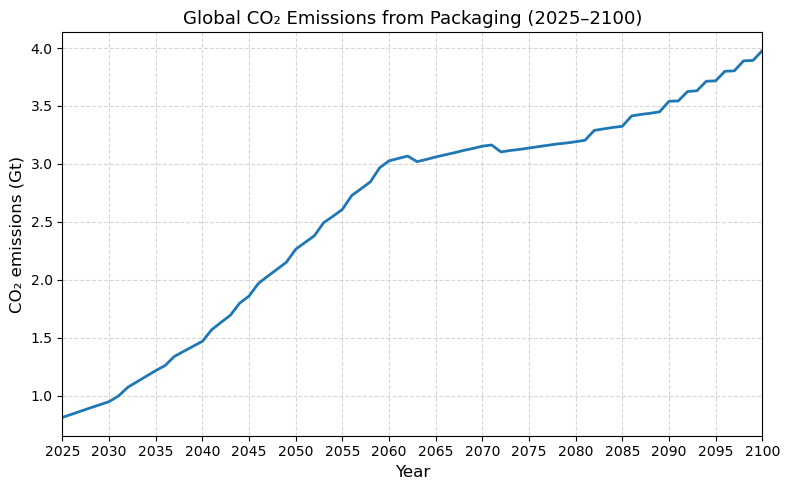

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Read the CO2 results
co2_by_year_ssp1_df = pd.read_csv("co2_by_year_ssp1.csv")

# Convert kg → gigatonnes (1 Gt = 1e12 kg)
co2_by_year_ssp1_df["CO2_Gt"] = co2_by_year_ssp1_df["co2_sum"] / 1e12

# Plot (line only, 5-year intervals)
plt.figure(figsize=(8,5))
plt.plot(co2_by_year_ssp1_df["year"], co2_by_year_ssp1_df["CO2_Gt"], linewidth=2)
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO₂ emissions (Gt)", fontsize=12)
plt.title("Global CO₂ Emissions from Packaging (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.tight_layout()

# Save the figure
plt.savefig("CO2_emissions_packaging_2025_2100.png", dpi=300)
plt.savefig("CO2_emissions_packaging_2025_2100.svg", format="svg")

# Show
plt.show()


### Plastic packaging stocks in the ocean

In [27]:
import numpy as np
import pandas as pd

# --- Inputs assumed available ---
# results: list of dicts with keys {"year","g_vector",...}
# B_index_df: has columns ["index","flow name","flow category"] aligned to rows of B

# --- Load flow lists and degradation constants ---
map_flows_df = pd.read_csv("data/MaP.csv")                         # column: "flow name"
k_df         = pd.read_csv("data/fragmentation_cons_yearly.csv")   # columns: "Flow", "fragmentation constant"

# Build: flow_name -> k  (default to 0 if not present)
k_map = {str(r["Flow"]): float(r["fragmentation constant"]) for _, r in k_df.iterrows()}

# Find B row indices for each MaP flow (group by flow name; keep all matches)
flow_to_bidx = {}
for fname in map_flows_df["flow name"].astype(str).unique():
    idxs = B_index_df.loc[B_index_df["flow name"].astype(str) == fname, "index"].astype(int).to_numpy()
    if idxs.size > 0:
        flow_to_bidx[fname] = idxs

if not flow_to_bidx:
    raise ValueError("No MaP flow rows from MaP.csv were found in B_index_df['flow name'].")

# Prepare iteration over years (sorted)
years_sorted = sorted(int(r["year"]) for r in results)
# Per-flow stock state at previous year (initialize to 0 at 2024)
stock_prev = {fname: 0.0 for fname in flow_to_bidx.keys()}

rows = []   # to collect yearly totals and per-flow stocks if desired

for y in years_sorted:
    # get g for this year
    g = next(r["g_vector"] for r in results if int(r["year"]) == y)

    # update each flow's stock with its own k and A_y (kg/year)
    stock_now = {}
    for fname, bidx in flow_to_bidx.items():
        k = float(k_map.get(fname, 0.0))
        A_y = float(np.nansum(g[bidx]))  # generated macroplastic for this flow in year y
        stock_now[fname] = stock_prev[fname] * np.exp(-k) + A_y

    # total MaP stock this year
    total_map = float(np.sum(list(stock_now.values())))

    rows.append({"year": y, "MaP_stock_kg": total_map})
    # carry state
    stock_prev = stock_now

# Save total stock by year
map_stock_df = pd.DataFrame(rows).sort_values("year")
map_stock_df.to_csv("macroplastic_stock_by_year_baseline.csv", index=False)

# (Optional) also save per-flow stocks for debugging/analysis
perflow_rows = []
# replay quickly to materialize per-flow time series
stock_prev = {fname: 0.0 for fname in flow_to_bidx.keys()}
for y in years_sorted:
    g = next(r["g_vector"] for r in results if int(r["year"]) == y)
    row = {"year": y}
    for fname, bidx in flow_to_bidx.items():
        k = float(k_map.get(fname, 0.0))
        A_y = float(np.nansum(g[bidx]))
        stock_prev[fname] = stock_prev[fname] * np.exp(-k) + A_y
        row[fname] = stock_prev[fname]
    perflow_rows.append(row)

pd.DataFrame(perflow_rows).to_csv("macroplastic_stock_per_flow_by_year.csv", index=False)

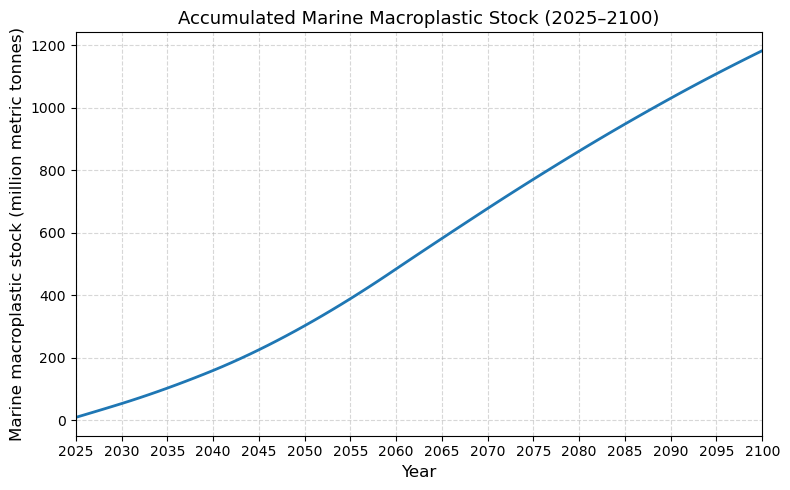

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the macroplastic stock results
map_stock_df = pd.read_csv("macroplastic_stock_by_year_baseline.csv")

# Convert kg → million metric tonnes (1 Mt = 1e9 kg)
map_stock_df["MaP_stock_Mt"] = map_stock_df["MaP_stock_kg"] / 1e9

# Plot
plt.figure(figsize=(8,5))
plt.plot(map_stock_df["year"], map_stock_df["MaP_stock_Mt"], linewidth=2)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Marine macroplastic stock (million metric tonnes)", fontsize=12)
plt.title("Accumulated Marine Macroplastic Stock (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.tight_layout()
plt.show()

In [31]:
import pandas as pd

# Read total macroplastic stocks by year
map_stock_df = pd.read_csv("macroplastic_stock_by_year_baseline.csv")

# Convert from kg to million metric tonnes (1 Mt = 1e9 kg)
map_stock_df["MaP_stock_Mt"] = map_stock_df["MaP_stock_kg"] / 1e9

# Extract as list
map_list = map_stock_df["MaP_stock_Mt"].tolist()

# Show results (optional)
for year, stock in zip(map_stock_df["year"], map_list):
    print(f"{year}: {stock:.3f} MMT")

# map_list now holds all yearly macroplastic stocks in MMT


2025: 8.593 MMT
2026: 17.268 MMT
2027: 26.023 MMT
2028: 34.858 MMT
2029: 43.773 MMT
2030: 52.766 MMT
2031: 62.071 MMT
2032: 71.681 MMT
2033: 81.590 MMT
2034: 91.791 MMT
2035: 102.278 MMT
2036: 113.044 MMT
2037: 124.083 MMT
2038: 135.390 MMT
2039: 146.959 MMT
2040: 158.785 MMT
2041: 171.096 MMT
2042: 183.882 MMT
2043: 197.131 MMT
2044: 210.832 MMT
2045: 224.976 MMT
2046: 239.551 MMT
2047: 254.549 MMT
2048: 269.959 MMT
2049: 285.773 MMT
2050: 301.983 MMT
2051: 318.578 MMT
2052: 335.551 MMT
2053: 352.895 MMT
2054: 370.600 MMT
2055: 388.660 MMT
2056: 407.067 MMT
2057: 425.815 MMT
2058: 444.895 MMT
2059: 464.302 MMT
2060: 484.030 MMT
2061: 503.680 MMT
2062: 523.258 MMT
2063: 542.767 MMT
2064: 562.213 MMT
2065: 581.598 MMT
2066: 600.927 MMT
2067: 620.203 MMT
2068: 639.430 MMT
2069: 658.611 MMT
2070: 677.749 MMT
2071: 696.731 MMT
2072: 715.561 MMT
2073: 734.247 MMT
2074: 752.795 MMT
2075: 771.208 MMT
2076: 789.494 MMT
2077: 807.656 MMT
2078: 825.701 MMT
2079: 843.632 MMT
2080: 861.454 MMT
208

In [100]:
import numpy as np
import pandas as pd

# Inputs assumed available:
# - results: list of dicts with keys {"year","g_vector", ...}
# - B_index_df: columns include ["index","flow name","flow category"]
# - MaP flows file: data/MaP.csv with column "flow name"

# 1) Load MaP flow names
map_flows_df = pd.read_csv("data/MaP.csv")  # has column "flow name"

# 2) Map each MaP flow -> row indices in B (can be multiple rows per flow)
flow_to_bidx = {}
for fname in map_flows_df["flow name"].astype(str).unique():
    idxs = B_index_df.loc[B_index_df["flow name"].astype(str) == fname, "index"].astype(int).to_numpy()
    if idxs.size > 0:
        flow_to_bidx[fname] = idxs

if not flow_to_bidx:
    raise ValueError("No MaP flow rows from MaP.csv were found in B_index_df.")

# 3) Compute A (annual generated macroplastic) per year, per flow (kg/yr)
years_sorted = sorted(int(r["year"]) for r in results)
A_rows = []
for y in years_sorted:
    g = next(r["g_vector"] for r in results if int(r["year"]) == y)
    rec = {"year": y}
    for flow, idxs in flow_to_bidx.items():
        rec[flow] = float(np.nansum(g[idxs]))  # annual inflow for that flow (kg)
    rec["A_total_kg"] = float(np.sum([rec[f] for f in flow_to_bidx.keys()]))
    A_rows.append(rec)

A_perflow_df = pd.DataFrame(A_rows).sort_values("year")
A_perflow_df.to_csv("A_generated_macroplastic_perflow_by_year.csv", index=False)

# 4) Also create a compact total-only table and MMT conversion
A_total_df = A_perflow_df[["year", "A_total_kg"]].copy()
A_total_df["A_total_Mt"] = A_total_df["A_total_kg"] / 1e9  # kg -> million metric tonnes
A_total_df.to_csv("A_generated_macroplastic_total_by_year.csv", index=False)

# 5) If you want the list in MMT (aligned with 2025..2100)
A_list_Mt = A_total_df["A_total_Mt"].tolist()

# (Optional) quick print preview
for yr, val in zip(A_total_df["year"], A_total_df["A_total_Mt"]):
    print(f"{yr}: {val:.3f} MMT")


2025: 8.593 MMT
2026: 8.906 MMT
2027: 9.218 MMT
2028: 9.531 MMT
2029: 9.843 MMT
2030: 10.156 MMT
2031: 10.703 MMT
2032: 11.250 MMT
2033: 11.796 MMT
2034: 12.343 MMT
2035: 12.890 MMT
2036: 13.437 MMT
2037: 13.984 MMT
2038: 14.531 MMT
2039: 15.077 MMT
2040: 15.624 MMT
2041: 16.406 MMT
2042: 17.187 MMT
2043: 17.968 MMT
2044: 18.749 MMT
2045: 19.530 MMT
2046: 20.312 MMT
2047: 21.093 MMT
2048: 21.874 MMT
2049: 22.655 MMT
2050: 23.436 MMT
2051: 24.218 MMT
2052: 24.999 MMT
2053: 25.780 MMT
2054: 26.561 MMT
2055: 27.343 MMT
2056: 28.124 MMT
2057: 28.905 MMT
2058: 29.686 MMT
2059: 30.467 MMT
2060: 31.249 MMT
2061: 31.639 MMT
2062: 32.030 MMT
2063: 32.420 MMT
2064: 32.811 MMT
2065: 33.202 MMT
2066: 33.592 MMT
2067: 33.983 MMT
2068: 34.374 MMT
2069: 34.764 MMT
2070: 35.155 MMT
2071: 35.428 MMT
2072: 35.702 MMT
2073: 35.975 MMT
2074: 36.248 MMT
2075: 36.522 MMT
2076: 36.795 MMT
2077: 37.069 MMT
2078: 37.342 MMT
2079: 37.616 MMT
2080: 37.889 MMT
2081: 38.084 MMT
2082: 38.280 MMT
2083: 38.475 MMT
20

In [34]:
import numpy as np
import pandas as pd

# --- Load data ---
mip_flows_df = pd.read_csv("data/MiP.csv")                  # direct microplastic flows
map_flows_df = pd.read_csv("data/MaP.csv")                  # macro flows (already used earlier)
k_df = pd.read_csv("data/fragmentation_cons_yearly.csv")    # macro→micro fragmentation
l_df = pd.read_csv("data/mineralization_cons_yearly.csv")   # micro→mineralization

# Create flow-to-index mappings
mip_flow_to_bidx = {
    fname: B_index_df.loc[B_index_df["flow name"].astype(str) == fname, "index"].astype(int).to_numpy()
    for fname in mip_flows_df["flow name"].astype(str).unique()
}
mip_flow_to_bidx = {k:v for k,v in mip_flow_to_bidx.items() if v.size > 0}

# Get constant values
k_mean = k_df["fragmentation constant"].mean()  # average across macro flows (or per-flow if available)
l_mean = l_df["mineralization constant"].mean() # micro→mineralization constant

# Load previously computed MAP stock data
map_stock_df = pd.read_csv("macroplastic_stock_by_year_baseline.csv")
map_stock_df = map_stock_df.sort_values("year")

# Initialize results
years = sorted(int(r["year"]) for r in results)
mip_stock_prev = 0.0
rows = []

for y in years:
    g = next(r["g_vector"] for r in results if int(r["year"]) == y)

    # X (direct microplastic generation) in kg
    X_y = sum(float(np.nansum(g[idxs])) for idxs in mip_flow_to_bidx.values())

    # MAP_n: macro stock for current year (kg)
    MAP_y = float(map_stock_df.loc[map_stock_df["year"] == y, "MaP_stock_kg"].iloc[0])

    # Apply equation: MiP_{n+1} = MiP_n e^{-l} + MAP_n (1 - e^{-k}) + X_{n+1}
    mip_stock_now = mip_stock_prev * np.exp(-l_mean) + MAP_y * (1 - np.exp(-k_mean)) + X_y

    rows.append({"year": y, "MiP_stock_kg": mip_stock_now})
    mip_stock_prev = mip_stock_now

# Store results
mip_stock_df = pd.DataFrame(rows).sort_values("year")
mip_stock_df["MiP_stock_Mt"] = mip_stock_df["MiP_stock_kg"] / 1e9  # convert kg → million metric tonnes
mip_stock_df.to_csv("microplastic_stock_by_year_baseline.csv", index=False)

# Quick preview
for yr, val in zip(mip_stock_df["year"], mip_stock_df["MiP_stock_Mt"]):
    print(f"{yr}: {val:.3f} MMT")


2025: 0.673 MMT
2026: 1.595 MMT
2027: 2.769 MMT
2028: 4.196 MMT
2029: 5.880 MMT
2030: 7.822 MMT
2031: 10.042 MMT
2032: 12.549 MMT
2033: 15.350 MMT
2034: 18.454 MMT
2035: 21.869 MMT
2036: 25.601 MMT
2037: 29.658 MMT
2038: 34.048 MMT
2039: 38.777 MMT
2040: 43.852 MMT
2041: 49.299 MMT
2042: 55.129 MMT
2043: 61.356 MMT
2044: 67.992 MMT
2045: 75.049 MMT
2046: 82.537 MMT
2047: 90.470 MMT
2048: 98.856 MMT
2049: 107.709 MMT
2050: 117.037 MMT
2051: 126.852 MMT
2052: 137.164 MMT
2053: 147.982 MMT
2054: 159.317 MMT
2055: 171.177 MMT
2056: 183.573 MMT
2057: 196.513 MMT
2058: 210.006 MMT
2059: 224.061 MMT
2060: 238.687 MMT
2061: 253.861 MMT
2062: 269.582 MMT
2063: 285.847 MMT
2064: 302.655 MMT
2065: 320.005 MMT
2066: 337.894 MMT
2067: 356.322 MMT
2068: 375.287 MMT
2069: 394.787 MMT
2070: 414.822 MMT
2071: 435.381 MMT
2072: 456.460 MMT
2073: 478.055 MMT
2074: 500.163 MMT
2075: 522.780 MMT
2076: 545.902 MMT
2077: 569.526 MMT
2078: 593.650 MMT
2079: 618.269 MMT
2080: 643.381 MMT
2081: 668.977 MMT
2082

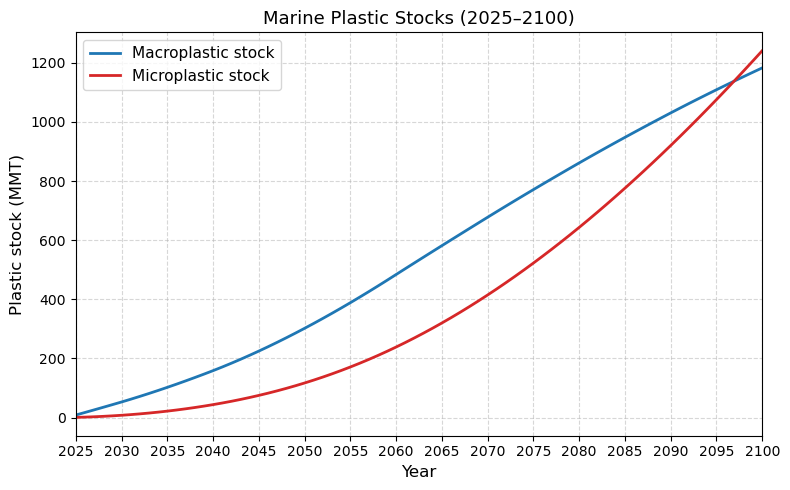

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load macro and micro stock data
map_df = pd.read_csv("macroplastic_stock_by_year_baseline.csv")
mip_df = pd.read_csv("microplastic_stock_by_year_baseline.csv")

# Ensure both are in MMT
map_df["MaP_stock_Mt"] = map_df["MaP_stock_kg"] / 1e9
mip_df["MiP_stock_Mt"] = mip_df["MiP_stock_kg"] / 1e9

# Merge by year
merged = pd.merge(map_df[["year", "MaP_stock_Mt"]],
                  mip_df[["year", "MiP_stock_Mt"]],
                  on="year", how="inner")

# Plot single axis with two series
plt.figure(figsize=(8,5))
plt.plot(merged["year"], merged["MaP_stock_Mt"], label="Macroplastic stock", linewidth=2, color="tab:blue")
plt.plot(merged["year"], merged["MiP_stock_Mt"], label="Microplastic stock", linewidth=2, color="tab:red")

plt.xlabel("Year", fontsize=12)
plt.ylabel("Plastic stock (MMT)", fontsize=12)
plt.title("Marine Plastic Stocks (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.legend(fontsize=11)
plt.tight_layout()

# Save the figure
plt.savefig("plastic_stocks.png", dpi=300)
plt.savefig("plastic_stocks.svg", format="svg")

plt.show()

# 2. Baseline SSP2

### Remove Carbon Capture

In [31]:
carbon_capture_decisions_df = pd.read_csv("data/carbon_capture_decisions.csv")

In [32]:
import numpy as np
import pandas as pd

# normalize for reliable matching
ekey = lambda s: str(s).strip().casefold()

# copies + keys
A_index_df = A_index_df.copy()
carbon_capture_decisions_df = carbon_capture_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
carbon_capture_decisions_df["col_key"] = carbon_capture_decisions_df["Provider name"].map(ekey)
carbon_capture_decisions_df["row_key"] = carbon_capture_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices (row/col) in A
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric X
carbon_capture_decisions_df["Linear Economy"] = pd.to_numeric(
    carbon_capture_decisions_df["Linear Economy"], errors="coerce"
)

# apply: for each decision row, A[row, col] *= X
n_pairs = 0
skipped = 0

for _, d in carbon_capture_decisions_df.iterrows():
    X = d["Linear Economy"]
    if pd.isna(X):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(X)
            n_pairs += 1

### Remove Microplastic treatment

In [33]:
microplastics_decisions_df = pd.read_csv("data/microplastics_decisions.csv")

In [34]:
import numpy as np
import pandas as pd

# normalizer
ekey = lambda s: str(s).strip().casefold()

# copies + normalized keys
A_index_df = A_index_df.copy()
microplastics_decisions_df = microplastics_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
microplastics_decisions_df["col_key"] = microplastics_decisions_df["Provider name"].map(ekey)
microplastics_decisions_df["row_key"] = microplastics_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices in A (rows/cols)
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric decision value
microplastics_decisions_df["No WWT Filtration"] = pd.to_numeric(
    microplastics_decisions_df["No WWT Filtration"], errors="coerce"
)

# apply decisions: A[row, col] *= value
n_pairs = 0
skipped = 0

for _, d in microplastics_decisions_df.iterrows():
    x = d["No WWT Filtration"]
    if pd.isna(x):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(x)
            n_pairs += 1

### Fix Bio-ethanol mix (25% of each second-gen)

In [35]:
import numpy as np
import pandas as pd

# Load the ethanol CSV
ethanol_df = pd.read_csv("data/dynamic ethanol.csv")

# Function to find index safely
def find_index(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Update A based on the baseline column
for _, r in ethanol_df.iterrows():
    provider = str(r["Provider name"])
    flow     = str(r["Input"])
    val      = float(r["baseline"])

    # Find indices
    row_idx = find_index(A_index_df, "flow name", flow)
    if row_idx is None:
        row_idx = find_index(A_index_df, "provider name", flow)
    col_idx = find_index(A_index_df, "provider name", provider)

    # Update A
    if (row_idx is not None) and (col_idx is not None):
        A[row_idx, col_idx] = val
    else:
        print(f"Warning: could not find indices for Provider={provider}, Flow={flow}")

### Baseline Collection & Sorting

In [36]:
packaging_types_df = pd.read_csv("data/packaging_types.csv")
collection_recyclate_df = pd.read_csv("data/collection_Recyclate.csv")
collection_msw_df = pd.read_csv("data/collection_MSW.csv")

In [37]:
import numpy as np
import pandas as pd
import re

# ---- exact-key matcher (case/space insensitive, keeps stage prefixes) ----
ekey = lambda s: str(s).strip().casefold()

# ---- copies + normalized keys ----
A_index_df = A_index_df.copy()
packaging_types_df = packaging_types_df.copy()
collection_msw_df = collection_msw_df.copy()

A_index_df["prov_exact"]         = A_index_df["provider name"].map(ekey)
packaging_types_df["prov_exact"] = packaging_types_df["provider name"].map(ekey)
collection_msw_df["prov_exact"]  = collection_msw_df["provider name"].map(ekey)

# If you know the 3 mapping columns, set them here, e.g.:
# mapping_cols = ["dest_1", "dest_2", "dest_3"]
# Otherwise, auto-detect up to 3 string columns besides 'provider name'
mapping_cols = [c for c in packaging_types_df.columns
                if c not in ("provider name", "prov_exact")
                and pd.api.types.is_string_dtype(packaging_types_df[c])][:3]
if not mapping_cols:
    raise ValueError("Couldn't detect mapping columns; please set 'mapping_cols' explicitly.")

# Normalize destination columns
for col in mapping_cols:
    packaging_types_df[col + "_exact"] = packaging_types_df[col].map(ekey)

# provider name -> list of integer indices in A (rows/cols)
idx_map_exact = (
    A_index_df.groupby("prov_exact")["index"]
              .apply(lambda s: list(map(int, s)))
              .to_dict()
)

# "Use & Collection" column index
use_col = int(A_index_df.loc[A_index_df["provider name"]=="Use & Collection","index"].iloc[0])

# ---- X: abs(A[row, use_col]) per packaging provider (exact match) ----
X_by_src = {}
for k in packaging_types_df["prov_exact"].dropna().unique():
    rows = idx_map_exact.get(k, [])
    if rows:
        r0 = int(rows[0])  # if multiple rows per provider, change to sum/mean if needed
        X_by_src[k] = abs(float(A[r0, use_col]))

# ---- Y: MSW "Linear Economy" per provider (exact match) ----
Y_by_key = (collection_msw_df.dropna(subset=["prov_exact"])
            .groupby("prov_exact")["Baseline - SSP2"]
            .first()
            .to_dict())

# ---- zero out destination cells we're going to rewrite (avoid accumulation on reruns) ----
dest_rows = set()
for _, row in packaging_types_df.iterrows():
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if dk in idx_map_exact:
            dest_rows.update(idx_map_exact[dk])
if dest_rows:
    A[list(dest_rows), use_col] = 0.0

# ---- assign: A[row, use_col] += X * Y for each mapped destination (exact match) ----
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X     = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

In [38]:
# --- Recyclate pass: X * Y_recyclate added into A[:, use_col] ---

collection_recyclate_df = collection_recyclate_df.copy()
collection_recyclate_df["prov_exact"] = collection_recyclate_df["provider name"].map(ekey)

# Y from recyclate
Y_rec_by_key = (
    collection_recyclate_df.dropna(subset=["prov_exact"])
    .groupby("prov_exact")["Baseline - SSP2"]
    .first()    # change to sum()/mean() if needed
    .to_dict()
)

# Optionally clear destination cells before this pass (default = keep MSW values and add recyclate)
reset_dest = False
if reset_dest:
    rec_dest_rows = set()
    for _, row in packaging_types_df.iterrows():
        for col in mapping_cols:
            dk = row.get(col + "_exact", None)
            rec_dest_rows.update(idx_map_exact.get(dk, []))
    if rec_dest_rows:
        A[np.array(sorted(rec_dest_rows), dtype=int), use_col] = 0.0

# Write: A[row, use_col] += X * Y_recyclate
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_rec_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

### Baseline Recycling

In [39]:
import numpy as np
import pandas as pd

# Load the CSV
recycling_df = pd.read_csv("data/dynamic-baseline-recycling.csv")

# Function to find index safely
def find_index(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Update A based on the baseline column
for _, r in recycling_df.iterrows():
    provider = str(r["Provider name"])
    flow     = str(r["Input parameters names"])
    val      = float(r["Baseline"])

    # Find indices
    row_idx = find_index(A_index_df, "flow name", flow)
    if row_idx is None:
        row_idx = find_index(A_index_df, "provider name", flow)
    col_idx = find_index(A_index_df, "provider name", provider)

    # Update A
    if (row_idx is not None) and (col_idx is not None):
        A[row_idx, col_idx] = val
    else:
        print(f"Warning: could not find indices for Provider={provider}, Flow={flow}")

In [40]:
A[A_index_df.loc[A_index_df['provider name'] == "Mechanical Recycling, HDPE Drinking Bottles (Flakes)", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Flakes, HDPE Drinking Bottles", 'index'].iloc[0]]

1.0

## Quality Scenario (for recycled material from mechanical)

In [41]:
quality_scenarios_df = pd.read_csv("data/quality_scenarios.csv")

In [42]:
# Assumes the following are already in memory:
# - quality_scenarios_df  with columns: "Recycling Process", "Substitutable Virgin Process", "S1 - no limit"
# - A_index_df            with columns: "Provider name", "Index"
# - A                     as a NumPy array (your A-matrix)

# Normalize helper (case-insensitive, trim spaces)
_norm = lambda s: str(s).strip().casefold()

# Build name -> index map from A_index_df
# If A_index_df['Index'] is 1-based, uncomment the "- 1" line below instead.
name_to_idx = {
    _norm(p): int(i)
    for p, i in zip(A_index_df["provider name"], A_index_df["index"])
    # for p, i in zip(A_index_df["Provider name"], A_index_df["Index"] - 1)  # <- use this if indices are 1-based
}

# Map processes to A indices
col_idx = quality_scenarios_df["Recycling Process"].astype(str).map(_norm).map(name_to_idx)
row_idx = quality_scenarios_df["Substitutable Virgin Process"].astype(str).map(_norm).map(name_to_idx)

# Save the pair (row, col) to the "Index" column
quality_scenarios_df["index"] = list(zip(row_idx, col_idx))

# Pull values to write
vals = pd.to_numeric(quality_scenarios_df["S1 - no limit"], errors="coerce")

# Only update where both indices and value are valid
mask = row_idx.notna() & col_idx.notna() & vals.notna()
rows = row_idx[mask].astype(int).to_numpy()
cols = col_idx[mask].astype(int).to_numpy()
v    = vals[mask].to_numpy(dtype=float)

# Write into A at (row, col)
A[rows, cols] = v

# Optional diagnostics:
# print("Updated entries:", mask.sum())
# print("Unmatched Recycling Process:", quality_scenarios_df.loc[col_idx.isna(), "Recycling Process"].drop_duplicates().tolist()[:10])
# print("Unmatched Substitutable Virgin Process:", quality_scenarios_df.loc[row_idx.isna(), "Substitutable Virgin Process"].drop_duplicates().tolist()[:10])


In [43]:
A[int(A_index_df.loc[A_index_df["provider name"]=="Polyethylene, high density, HDPE, virgin resin, food non-bottle grade","index"].iloc[0]),
  int(A_index_df.loc[A_index_df["provider name"]=="Mechanical Recycling, HDPE Other Food Rigid (Flakes)","index"].iloc[0])]

1.0

## Dynamic LCA

In [44]:
import numpy as np
import pandas as pd

# -----------------------------
# Load data
# -----------------------------
electricity_mix_df = pd.read_csv("data/electricity_mix_2025_2100.csv")
iam_indices_df     = pd.read_csv("data/iam-indices.csv")
packaging_df       = pd.read_csv("data/packaging_production_manual_2025_2100_kg.csv")

# Oil vs Natural Gas
ratio_oil_ng_df = pd.read_csv("data/ratio_oil_vs_natural_gas_2025_2100.csv")
map_oil_ng_df   = pd.read_csv("data/oil-vs-NG-feedstock.csv")

# Biomass vs Fossil
ratio_bio_fossil_df = pd.read_csv("data/ratio_biomass_vs_total_2025_2100.csv")
map_bio_fossil_df   = pd.read_csv("data/bio-vs-fossil feedstock.csv")

# -----------------------------
# Helpers
# -----------------------------
def first_idx(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Electricity Mix (Global) column index in A
mix_idx = int(A_index_df.loc[A_index_df['provider name'] == "Electricity Mix (Global)", 'index'].iloc[0])

# Map IAM electricity sources -> A row indices
iam_to_A = {}
for _, r in iam_indices_df.iterrows():
    lci_name = r["LCI Index"]
    hit = A_index_df.loc[A_index_df["provider name"] == lci_name, "index"]
    if not hit.empty:
        iam_to_A[str(r["IAM Index"])] = int(hit.iloc[0])

# -----------------------------
# Feedstock targets
# -----------------------------
feedstock_targets_oil_ng = []
for _, r in map_oil_ng_df.iterrows():
    dyn_name, prov_name, input_name = str(r["dynamic csv name"]), str(r["Provider name"]), str(r["Input parameters names"])
    row_idx = first_idx(A_index_df, "flow name", input_name) or first_idx(A_index_df, "provider name", input_name)
    col_idx = first_idx(A_index_df, "provider name", prov_name)
    if (row_idx is not None) and (col_idx is not None):
        feedstock_targets_oil_ng.append((dyn_name, row_idx, col_idx))

feedstock_targets_bio_fossil = []
for _, r in map_bio_fossil_df.iterrows():
    dyn_name, prov_name, input_name = str(r["dynamic csv name"]), str(r["Provider name"]), str(r["Input parameters names"])
    row_idx = first_idx(A_index_df, "flow name", input_name) or first_idx(A_index_df, "provider name", input_name)
    col_idx = first_idx(A_index_df, "provider name", prov_name)
    if (row_idx is not None) and (col_idx is not None):
        feedstock_targets_bio_fossil.append((dyn_name, row_idx, col_idx))

# Pre-index ratio tables
ratio_oil_ng_by_year     = ratio_oil_ng_df.set_index("Year")
ratio_bio_fossil_by_year = ratio_bio_fossil_df.set_index("Year")

# -----------------------------
# Merge electricity mix and packaging data
# -----------------------------
merged_df = electricity_mix_df.merge(packaging_df, on="Year", how="inner")

results   = []
A_by_year = {}
f = np.zeros(len(A))

# -----------------------------
# Dynamic loop
# -----------------------------
for _, row in merged_df.iterrows():
    year = int(row["Year"])

    # 1) Build f
    n = A.shape[0]
    f = np.zeros(n)
    f[0] = float(row["Packaging_Plastic_kg"])

    # 2) Copy A and apply updates
    A_dyn = A.copy()

    # (a) Electricity mix: negative since it's an input
    for iam_source, idx in iam_to_A.items():
        if iam_source in row.index:
            A_dyn[idx, mix_idx] = -abs(float(row[iam_source]))/100

    # (b) Oil vs Natural Gas: negative since input
    if year in ratio_oil_ng_by_year.index:
        r_year = ratio_oil_ng_by_year.loc[year]
        for dyn_name, r_idx, c_idx in feedstock_targets_oil_ng:
            if dyn_name in r_year.index:
                A_dyn[r_idx, c_idx] = -abs(float(r_year[dyn_name]))

    # (c) Biomass vs Fossil: negative since input
    if year in ratio_bio_fossil_by_year.index:
        r_year_bf = ratio_bio_fossil_by_year.loc[year]
        for dyn_name, r_idx, c_idx in feedstock_targets_bio_fossil:
            if dyn_name in r_year_bf.index:
                A_dyn[r_idx, c_idx] = -abs(float(r_year_bf[dyn_name]))

    # 3) Solve As = f
    s = np.linalg.solve(A_dyn, f)

    # 4) g = Bs
    g = B @ s

    # 5) Store results
    results.append({
        "year": year,
        "packaging_demand_kg": f[0],
        "g_vector": g,
        "s_vector": s
    })

    # 6) Store dynamic A
    A_by_year[year] = A_dyn.copy()

In [45]:
g_2100 = next(r['g_vector'] for r in results if r['year'] == 2100)

In [46]:
s_2100 = next(r['s_vector'] for r in results if r['year'] == 2100)

In [47]:
A_2100 = A_by_year[2100]

In [48]:
A_2100[A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride monomer, EDC-VCM; from bio-ethylene", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride", 'index'].iloc[0]]

-0.15

### CO2 emissions 

In [49]:
import numpy as np
import pandas as pd

# Read target CO2 flows (names + categories)
co2_df = pd.read_csv("data/CO2.csv")  # cols: "flow name","flow category"

# Build a set of (name, category) pairs to match
target_pairs = set(zip(co2_df["flow name"].astype(str), co2_df["flow category"].astype(str)))

# Find matching row indices in B_index_df
mask = B_index_df.apply(
    lambda r: (str(r["flow name"]), str(r["flow category"])) in target_pairs, axis=1
)
co2_idx = B_index_df.loc[mask, "index"].astype(int).to_numpy()

if co2_idx.size == 0:
    raise ValueError("No CO2 flow rows found in B_index_df matching CO2.csv")

# Build per-year CO2 totals by summing g on those indices
co2_by_year = []
for r in results:
    g = r["g_vector"]
    year = int(r["year"])
    co2_sum = float(np.nansum(g[co2_idx]))
    co2_by_year.append({"year": year, "co2_sum": co2_sum})

co2_by_year_ssp2_df = pd.DataFrame(co2_by_year).sort_values("year")
co2_by_year_ssp2_df.to_csv("co2_by_year_ssp2.csv", index=False)

# Optional: keep indices used for traceability
pd.Series(co2_idx, name="co2_row_indices_in_B").to_csv("co2_row_indices_used.csv", index=False)

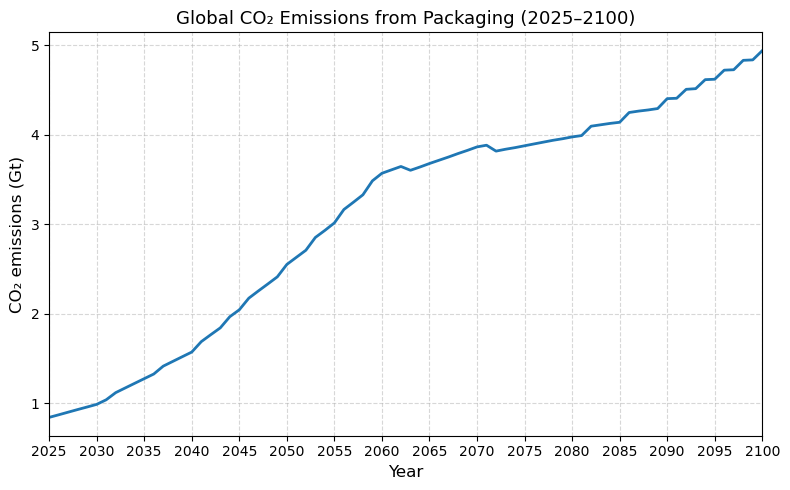

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Read the CO2 results
co2_by_year_df = pd.read_csv("co2_by_year_ssp2.csv")

# Convert kg → gigatonnes (1 Gt = 1e12 kg)
co2_by_year_df["CO2_Gt"] = co2_by_year_df["co2_sum"] / 1e12

# Plot (line only, 5-year intervals)
plt.figure(figsize=(8,5))
plt.plot(co2_by_year_df["year"], co2_by_year_df["CO2_Gt"], linewidth=2)
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO₂ emissions (Gt)", fontsize=12)
plt.title("Global CO₂ Emissions from Packaging (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.tight_layout()

# Save the figure
plt.savefig("CO2_emissions_packaging_2025_2100.png", dpi=300)
plt.savefig("CO2_emissions_packaging_2025_2100.svg", format="svg")

# Show
plt.show()


# 3. Baseline SSP1 - With Bio/EoL/CCS technologies available immidiately today (Best)

### Add Carbon Capture

In [51]:
carbon_capture_decisions_df = pd.read_csv("data/carbon_capture_decisions.csv")

In [52]:
import numpy as np
import pandas as pd

# normalize for reliable matching
ekey = lambda s: str(s).strip().casefold()

# copies + keys
A_index_df = A_index_df.copy()
carbon_capture_decisions_df = carbon_capture_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
carbon_capture_decisions_df["col_key"] = carbon_capture_decisions_df["Provider name"].map(ekey)
carbon_capture_decisions_df["row_key"] = carbon_capture_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices (row/col) in A
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric X
carbon_capture_decisions_df["Best"] = pd.to_numeric(
    carbon_capture_decisions_df["Best"], errors="coerce"
)

# apply: for each decision row, A[row, col] *= X
n_pairs = 0
skipped = 0

for _, d in carbon_capture_decisions_df.iterrows():
    X = d["Best"]
    if pd.isna(X):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(X)
            n_pairs += 1

### Add Microplastic treatment

In [53]:
microplastics_decisions_df = pd.read_csv("data/microplastics_decisions.csv")

In [54]:
import numpy as np
import pandas as pd

# normalizer
ekey = lambda s: str(s).strip().casefold()

# copies + normalized keys
A_index_df = A_index_df.copy()
microplastics_decisions_df = microplastics_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
microplastics_decisions_df["col_key"] = microplastics_decisions_df["Provider name"].map(ekey)
microplastics_decisions_df["row_key"] = microplastics_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices in A (rows/cols)
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric decision value
microplastics_decisions_df["WWT Filtration"] = pd.to_numeric(
    microplastics_decisions_df["WWT Filtration"], errors="coerce"
)

# apply decisions: A[row, col] *= value
n_pairs = 0
skipped = 0

for _, d in microplastics_decisions_df.iterrows():
    x = d["WWT Filtration"]
    if pd.isna(x):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(x)
            n_pairs += 1

### Fix Bio-ethanol mix (25% of each second-gen)

In [55]:
import numpy as np
import pandas as pd

# Load the ethanol CSV
ethanol_df = pd.read_csv("data/dynamic ethanol.csv")

# Function to find index safely
def find_index(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Update A based on the baseline column
for _, r in ethanol_df.iterrows():
    provider = str(r["Provider name"])
    flow     = str(r["Input"])
    val      = float(r["baseline"])

    # Find indices
    row_idx = find_index(A_index_df, "flow name", flow)
    if row_idx is None:
        row_idx = find_index(A_index_df, "provider name", flow)
    col_idx = find_index(A_index_df, "provider name", provider)

    # Update A
    if (row_idx is not None) and (col_idx is not None):
        A[row_idx, col_idx] = val
    else:
        print(f"Warning: could not find indices for Provider={provider}, Flow={flow}")

### Baseline Collection & Sorting

In [56]:
packaging_types_df = pd.read_csv("data/packaging_types.csv")
collection_recyclate_df = pd.read_csv("data/collection_Recyclate.csv")
collection_msw_df = pd.read_csv("data/collection_MSW.csv")

In [57]:
import numpy as np
import pandas as pd
import re

# ---- exact-key matcher (case/space insensitive, keeps stage prefixes) ----
ekey = lambda s: str(s).strip().casefold()

# ---- copies + normalized keys ----
A_index_df = A_index_df.copy()
packaging_types_df = packaging_types_df.copy()
collection_msw_df = collection_msw_df.copy()

A_index_df["prov_exact"]         = A_index_df["provider name"].map(ekey)
packaging_types_df["prov_exact"] = packaging_types_df["provider name"].map(ekey)
collection_msw_df["prov_exact"]  = collection_msw_df["provider name"].map(ekey)

# If you know the 3 mapping columns, set them here, e.g.:
# mapping_cols = ["dest_1", "dest_2", "dest_3"]
# Otherwise, auto-detect up to 3 string columns besides 'provider name'
mapping_cols = [c for c in packaging_types_df.columns
                if c not in ("provider name", "prov_exact")
                and pd.api.types.is_string_dtype(packaging_types_df[c])][:3]
if not mapping_cols:
    raise ValueError("Couldn't detect mapping columns; please set 'mapping_cols' explicitly.")

# Normalize destination columns
for col in mapping_cols:
    packaging_types_df[col + "_exact"] = packaging_types_df[col].map(ekey)

# provider name -> list of integer indices in A (rows/cols)
idx_map_exact = (
    A_index_df.groupby("prov_exact")["index"]
              .apply(lambda s: list(map(int, s)))
              .to_dict()
)

# "Use & Collection" column index
use_col = int(A_index_df.loc[A_index_df["provider name"]=="Use & Collection","index"].iloc[0])

# ---- X: abs(A[row, use_col]) per packaging provider (exact match) ----
X_by_src = {}
for k in packaging_types_df["prov_exact"].dropna().unique():
    rows = idx_map_exact.get(k, [])
    if rows:
        r0 = int(rows[0])  # if multiple rows per provider, change to sum/mean if needed
        X_by_src[k] = abs(float(A[r0, use_col]))

# ---- Y: MSW "Linear Economy" per provider (exact match) ----
Y_by_key = (collection_msw_df.dropna(subset=["prov_exact"])
            .groupby("prov_exact")["High-tech"]
            .first()
            .to_dict())

# ---- zero out destination cells we're going to rewrite (avoid accumulation on reruns) ----
dest_rows = set()
for _, row in packaging_types_df.iterrows():
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if dk in idx_map_exact:
            dest_rows.update(idx_map_exact[dk])
if dest_rows:
    A[list(dest_rows), use_col] = 0.0

# ---- assign: A[row, use_col] += X * Y for each mapped destination (exact match) ----
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X     = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

In [58]:
# --- Recyclate pass: X * Y_recyclate added into A[:, use_col] ---

collection_recyclate_df = collection_recyclate_df.copy()
collection_recyclate_df["prov_exact"] = collection_recyclate_df["provider name"].map(ekey)

# Y from recyclate
Y_rec_by_key = (
    collection_recyclate_df.dropna(subset=["prov_exact"])
    .groupby("prov_exact")["High-tech"]
    .first()    # change to sum()/mean() if needed
    .to_dict()
)

# Optionally clear destination cells before this pass (default = keep MSW values and add recyclate)
reset_dest = False
if reset_dest:
    rec_dest_rows = set()
    for _, row in packaging_types_df.iterrows():
        for col in mapping_cols:
            dk = row.get(col + "_exact", None)
            rec_dest_rows.update(idx_map_exact.get(dk, []))
    if rec_dest_rows:
        A[np.array(sorted(rec_dest_rows), dtype=int), use_col] = 0.0

# Write: A[row, use_col] += X * Y_recyclate
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_rec_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

### Baseline Recycling

In [59]:
import numpy as np
import pandas as pd

# Load the CSV
recycling_df = pd.read_csv("data/dynamic-baseline-recycling-best.csv")

# Function to find index safely
def find_index(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Update A based on the baseline column
for _, r in recycling_df.iterrows():
    provider = str(r["Provider name"])
    flow     = str(r["Input parameters names"])
    val      = float(r["best case"])

    # Find indices
    row_idx = find_index(A_index_df, "flow name", flow)
    if row_idx is None:
        row_idx = find_index(A_index_df, "provider name", flow)
    col_idx = find_index(A_index_df, "provider name", provider)

    # Update A
    if (row_idx is not None) and (col_idx is not None):
        A[row_idx, col_idx] = val
    else:
        print(f"Warning: could not find indices for Provider={provider}, Flow={flow}")

In [60]:
A[A_index_df.loc[A_index_df['provider name'] == "Mechanical Recycling, HDPE Drinking Bottles (Flakes)", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Flakes, HDPE Drinking Bottles", 'index'].iloc[0]]

1.0

## Monomers

In [61]:
monomers_decisions_df = pd.read_csv("data/monomers_decisions.csv")

In [62]:
import numpy as np
import pandas as pd

# ---- helper: normalize names for reliable matching ----
ekey = lambda s: str(s).strip().casefold()

# ---- defensive copies + normalized keys ----
A_index_df = A_index_df.copy()
monomers_decisions_df = monomers_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
monomers_decisions_df["col_key"]  = monomers_decisions_df["Provider name"].map(ekey)
monomers_decisions_df["row_key"]  = monomers_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices in A (rows/cols)
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure "Linear Economy" is numeric
monomers_decisions_df["Best"] = pd.to_numeric(
    monomers_decisions_df["Best"], errors="coerce"
)

# ---- apply updates: for each row in decisions, scale A[row_idx, col_idx] *= X ----
n_pairs = 0
skipped = 0

for _, drow in monomers_decisions_df.iterrows():
    x = drow["Best"]
    if pd.isna(x):
        skipped += 1
        continue

    row_idxs = idx_map.get(drow["row_key"], [])
    col_idxs = idx_map.get(drow["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    # multiply all combinations (row, col) by X
    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(x)
            n_pairs += 1

In [63]:
A[A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride monomer, EDC-VCM; from bio-ethylene", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride", 'index'].iloc[0]]

-1.0

## Quality Scenario (for recycled material from mechanical)

In [64]:
quality_scenarios_df = pd.read_csv("data/quality_scenarios.csv")

In [65]:
# Assumes the following are already in memory:
# - quality_scenarios_df  with columns: "Recycling Process", "Substitutable Virgin Process", "S1 - no limit"
# - A_index_df            with columns: "Provider name", "Index"
# - A                     as a NumPy array (your A-matrix)

# Normalize helper (case-insensitive, trim spaces)
_norm = lambda s: str(s).strip().casefold()

# Build name -> index map from A_index_df
# If A_index_df['Index'] is 1-based, uncomment the "- 1" line below instead.
name_to_idx = {
    _norm(p): int(i)
    for p, i in zip(A_index_df["provider name"], A_index_df["index"])
    # for p, i in zip(A_index_df["Provider name"], A_index_df["Index"] - 1)  # <- use this if indices are 1-based
}

# Map processes to A indices
col_idx = quality_scenarios_df["Recycling Process"].astype(str).map(_norm).map(name_to_idx)
row_idx = quality_scenarios_df["Substitutable Virgin Process"].astype(str).map(_norm).map(name_to_idx)

# Save the pair (row, col) to the "Index" column
quality_scenarios_df["index"] = list(zip(row_idx, col_idx))

# Pull values to write
vals = pd.to_numeric(quality_scenarios_df["S1 - no limit"], errors="coerce")

# Only update where both indices and value are valid
mask = row_idx.notna() & col_idx.notna() & vals.notna()
rows = row_idx[mask].astype(int).to_numpy()
cols = col_idx[mask].astype(int).to_numpy()
v    = vals[mask].to_numpy(dtype=float)

# Write into A at (row, col)
A[rows, cols] = v

# Optional diagnostics:
# print("Updated entries:", mask.sum())
# print("Unmatched Recycling Process:", quality_scenarios_df.loc[col_idx.isna(), "Recycling Process"].drop_duplicates().tolist()[:10])
# print("Unmatched Substitutable Virgin Process:", quality_scenarios_df.loc[row_idx.isna(), "Substitutable Virgin Process"].drop_duplicates().tolist()[:10])


In [66]:
A[int(A_index_df.loc[A_index_df["provider name"]=="Polyethylene, high density, HDPE, virgin resin, food non-bottle grade","index"].iloc[0]),
  int(A_index_df.loc[A_index_df["provider name"]=="Mechanical Recycling, HDPE Other Food Rigid (Flakes)","index"].iloc[0])]

1.0

## Dynamic LCA

In [67]:
import numpy as np
import pandas as pd

# -----------------------------
# Load data
# -----------------------------
electricity_mix_df = pd.read_csv("data/electricity_mix_2025_2100_ssp1.csv")
iam_indices_df     = pd.read_csv("data/iam-indices.csv")
packaging_df       = pd.read_csv("data/packaging_production_manual_2025_2100_kg.csv")

# -----------------------------
# Helpers
# -----------------------------
def first_idx(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Electricity Mix (Global) column index in A
mix_idx = int(A_index_df.loc[A_index_df['provider name'] == "Electricity Mix (Global)", 'index'].iloc[0])

# Map IAM electricity sources -> A row indices
iam_to_A = {}
for _, r in iam_indices_df.iterrows():
    lci_name = r["LCI Index"]
    hit = A_index_df.loc[A_index_df["provider name"] == lci_name, "index"]
    if not hit.empty:
        iam_to_A[str(r["IAM Index"])] = int(hit.iloc[0])

# -----------------------------
# Merge electricity mix and packaging data
# -----------------------------
merged_df = electricity_mix_df.merge(packaging_df, on="Year", how="inner")

results   = []
A_by_year = {}
f = np.zeros(len(A))

# -----------------------------
# Dynamic loop
# -----------------------------
for _, row in merged_df.iterrows():
    year = int(row["Year"])

    # 1) Build f
    n = A.shape[0]
    f = np.zeros(n)
    f[0] = float(row["Packaging_Plastic_kg"])

    # 2) Copy A and apply updates
    A_dyn = A.copy()

    # (a) Electricity mix: negative since it's an input
    for iam_source, idx in iam_to_A.items():
        if iam_source in row.index:
            A_dyn[idx, mix_idx] = -abs(float(row[iam_source]))/100

    # 3) Solve As = f
    s = np.linalg.solve(A_dyn, f)

    # 4) g = Bs
    g = B @ s

    # 5) Store results
    results.append({
        "year": year,
        "packaging_demand_kg": f[0],
        "g_vector": g,
        "s_vector": s
    })

    # 6) Store dynamic A
    A_by_year[year] = A_dyn.copy()

In [68]:
g_2100 = next(r['g_vector'] for r in results if r['year'] == 2100)

In [69]:
s_2100 = next(r['s_vector'] for r in results if r['year'] == 2100)

In [70]:
A_2100 = A_by_year[2100]

In [71]:
A_2100[A_index_df.loc[A_index_df['provider name'] == "Ethanol production, wheat straw, biochemical", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Ethanol (bio-mix)", 'index'].iloc[0]]

-0.25

### CO2 emissions 

In [72]:
import numpy as np
import pandas as pd

# Read target CO2 flows (names + categories)
co2_df = pd.read_csv("data/CO2.csv")  # cols: "flow name","flow category"

# Build a set of (name, category) pairs to match
target_pairs = set(zip(co2_df["flow name"].astype(str), co2_df["flow category"].astype(str)))

# Find matching row indices in B_index_df
mask = B_index_df.apply(
    lambda r: (str(r["flow name"]), str(r["flow category"])) in target_pairs, axis=1
)
co2_idx = B_index_df.loc[mask, "index"].astype(int).to_numpy()

if co2_idx.size == 0:
    raise ValueError("No CO2 flow rows found in B_index_df matching CO2.csv")

# Build per-year CO2 totals by summing g on those indices
co2_by_year = []
for r in results:
    g = r["g_vector"]
    year = int(r["year"])
    co2_sum = float(np.nansum(g[co2_idx]))
    co2_by_year.append({"year": year, "co2_sum": co2_sum})

co2_by_year_ssp1_best_df = pd.DataFrame(co2_by_year).sort_values("year")
co2_by_year_ssp1_best_df.to_csv("co2_by_year_ssp1_best.csv", index=False)

# Optional: keep indices used for traceability
pd.Series(co2_idx, name="co2_row_indices_in_B").to_csv("co2_row_indices_used.csv", index=False)

In [73]:
co2_by_year_ssp1_best_df.loc[co2_by_year_ssp1_best_df["year"] == 2025, "co2_sum"].iloc[0]

1592817423511.4622

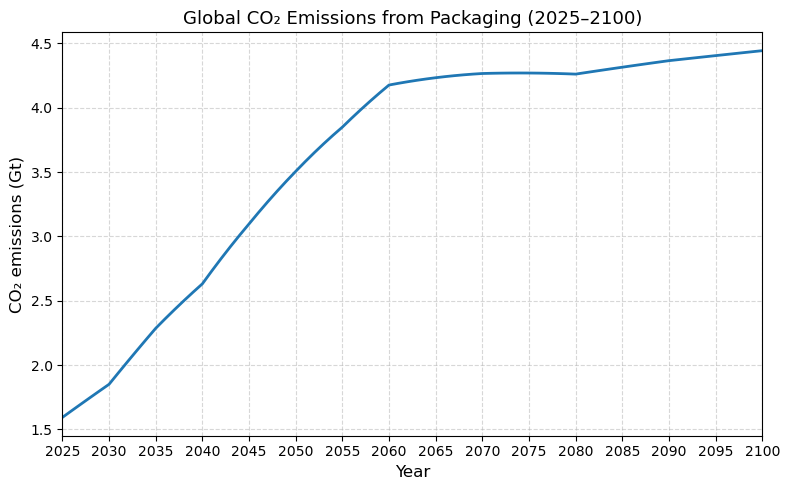

In [74]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Read the CO2 results
co2_by_year_ssp1_best_df = pd.read_csv("co2_by_year_ssp1_best.csv")

# Convert kg → gigatonnes (1 Gt = 1e12 kg)
co2_by_year_ssp1_best_df["CO2_Gt"] = co2_by_year_ssp1_best_df["co2_sum"] / 1e12

# Plot (line only, 5-year intervals)
plt.figure(figsize=(8,5))
plt.plot(co2_by_year_ssp1_best_df["year"], co2_by_year_ssp1_best_df["CO2_Gt"], linewidth=2)
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO₂ emissions (Gt)", fontsize=12)
plt.title("Global CO₂ Emissions from Packaging (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.tight_layout()

# Save the figure
plt.savefig("CO2_emissions_packaging_2025_2100.png", dpi=300)
plt.savefig("CO2_emissions_packaging_2025_2100.svg", format="svg")

# Show
plt.show()


In [75]:
s_2100 = next(r['s_vector'] for r in results if r['year'] == 2100)

In [76]:
# LCA Hotspots
# Impact per provider for category 0
CB = C @ B                                  # (n_impacts × n_providers)
contrib = s_2100 * CB[0, :]                      # contribution per provider
total_phi0 = contrib.sum()

# Use provider names from A_index_df
df = pd.DataFrame({
    "provider_name": A_index_df["provider name"].values,  # adjust column name if needed
    "contribution": contrib
})
df["share_%"] = 100 * df["contribution"] / total_phi0

# Top 10 contributors (by signed value)
top10 = df.sort_values("contribution", ascending=False).head(10)
print("\nTop 10 contributors to phi[0]:")
print(top10.reset_index(drop=True))

# If you want absolute-value ranking (credits vs burdens):
top10_abs = df.iloc[df["contribution"].abs().sort_values(ascending=False).index].head(10)
print("\nTop 10 contributors to phi[x] (absolute):")
print(top10_abs.reset_index(drop=True))


Top 10 contributors to phi[0]:
                                     provider_name  contribution    share_%
0      Natural gas, combusted in industrial boiler  2.446023e+12  45.322961
1            Muconic acid, fermentation of glucose  7.108857e+11  13.172176
2                      Switchgrass, harvested, wet  3.122040e+11   5.784904
3  Bituminous coal, combusted in industrial boiler  2.198966e+11   4.074518
4                  Electricity, solar (life cycle)  1.310984e+11   2.429155
5        Diesel, combusted in industrial equipment  1.169905e+11   2.167746
6                              Quicklime, at plant  8.863371e+10   1.642316
7            Electricity, natural gas (life cycle)  8.777821e+10   1.626464
8                   Electricity, coal (life cycle)  8.430209e+10   1.562054
9              Corn, decomposition, 15.5% moisture  7.433348e+10   1.377343

Top 10 contributors to phi[x] (absolute):
                                     provider_name  contribution    share_%
0      Natura

### Plastic packaging stocks in the ocean

In [47]:
import numpy as np
import pandas as pd

# --- Inputs assumed available ---
# results: list of dicts with keys {"year","g_vector",...}
# B_index_df: has columns ["index","flow name","flow category"] aligned to rows of B

# --- Load flow lists and degradation constants ---
map_flows_df = pd.read_csv("data/MaP.csv")                         # column: "flow name"
k_df         = pd.read_csv("data/fragmentation_cons_yearly.csv")   # columns: "Flow", "fragmentation constant"

# Build: flow_name -> k  (default to 0 if not present)
k_map = {str(r["Flow"]): float(r["fragmentation constant"]) for _, r in k_df.iterrows()}

# Find B row indices for each MaP flow (group by flow name; keep all matches)
flow_to_bidx = {}
for fname in map_flows_df["flow name"].astype(str).unique():
    idxs = B_index_df.loc[B_index_df["flow name"].astype(str) == fname, "index"].astype(int).to_numpy()
    if idxs.size > 0:
        flow_to_bidx[fname] = idxs

if not flow_to_bidx:
    raise ValueError("No MaP flow rows from MaP.csv were found in B_index_df['flow name'].")

# Prepare iteration over years (sorted)
years_sorted = sorted(int(r["year"]) for r in results)
# Per-flow stock state at previous year (initialize to 0 at 2024)
stock_prev = {fname: 0.0 for fname in flow_to_bidx.keys()}

rows = []   # to collect yearly totals and per-flow stocks if desired

for y in years_sorted:
    # get g for this year
    g = next(r["g_vector"] for r in results if int(r["year"]) == y)

    # update each flow's stock with its own k and A_y (kg/year)
    stock_now = {}
    for fname, bidx in flow_to_bidx.items():
        k = float(k_map.get(fname, 0.0))
        A_y = float(np.nansum(g[bidx]))  # generated macroplastic for this flow in year y
        stock_now[fname] = stock_prev[fname] * np.exp(-k) + A_y

    # total MaP stock this year
    total_map = float(np.sum(list(stock_now.values())))

    rows.append({"year": y, "MaP_stock_kg": total_map})
    # carry state
    stock_prev = stock_now

# Save total stock by year
map_stock_df = pd.DataFrame(rows).sort_values("year")
map_stock_df.to_csv("macroplastic_stock_by_year.csv", index=False)

# (Optional) also save per-flow stocks for debugging/analysis
perflow_rows = []
# replay quickly to materialize per-flow time series
stock_prev = {fname: 0.0 for fname in flow_to_bidx.keys()}
for y in years_sorted:
    g = next(r["g_vector"] for r in results if int(r["year"]) == y)
    row = {"year": y}
    for fname, bidx in flow_to_bidx.items():
        k = float(k_map.get(fname, 0.0))
        A_y = float(np.nansum(g[bidx]))
        stock_prev[fname] = stock_prev[fname] * np.exp(-k) + A_y
        row[fname] = stock_prev[fname]
    perflow_rows.append(row)

pd.DataFrame(perflow_rows).to_csv("macroplastic_stock_per_flow_by_year.csv", index=False)

In [48]:
import numpy as np
import pandas as pd

# Assumed available: results, B_index_df, map_flows_df (col "flow name"), k_df (cols "Flow","fragmentation constant")

# Map flow -> k
k_map = {str(r["Flow"]): float(r["fragmentation constant"]) for _, r in k_df.iterrows()}

# Map flow -> B row indices (each flow has its own set)
flow_to_bidx = {
    fname: B_index_df.loc[B_index_df["flow name"].astype(str)==fname, "index"].astype(int).to_numpy()
    for fname in map_flows_df["flow name"].astype(str).unique()
}
flow_to_bidx = {k:v for k,v in flow_to_bidx.items() if v.size>0}

years = sorted(int(r["year"]) for r in results)

# Initialize per-flow stocks at 0 for 2024
stock_prev = {flow: 0.0 for flow in flow_to_bidx.keys()}
rows = []                 # total per year (optional)
perflow_rows = []         # per-flow series (recommended)

for y in years:
    g = next(r["g_vector"] for r in results if int(r["year"])==y)
    stock_now = {}

    for flow, idxs in flow_to_bidx.items():
        k = float(k_map.get(flow, 0.0))
        decay = np.exp(-k)        # use (1 - k) instead if k is an annual fraction
        A_y = float(np.nansum(g[idxs]))  # this flow’s macroplastic generated in year y
        stock_now[flow] = stock_prev[flow] * decay + A_y

    # save per-flow stocks for this year
    rec = {"year": y}
    rec.update(stock_now)
    perflow_rows.append(rec)

    # optional total AFTER per-flow updates
    rows.append({"year": y, "MaP_stock_kg": float(sum(stock_now.values()))})

    # roll forward state
    stock_prev = stock_now

# DataFrames
map_stock_best_df      = pd.DataFrame(rows).sort_values("year")              # total (optional)
map_stock_best_perflow = pd.DataFrame(perflow_rows).sort_values("year")      # per-flow (preferred)

# Example save
map_stock_best_df.to_csv("macroplastic_stock_by_year_best.csv", index=False)
map_stock_best_perflow.to_csv("macroplastic_stock_best_per_flow_by_year_best.csv", index=False)

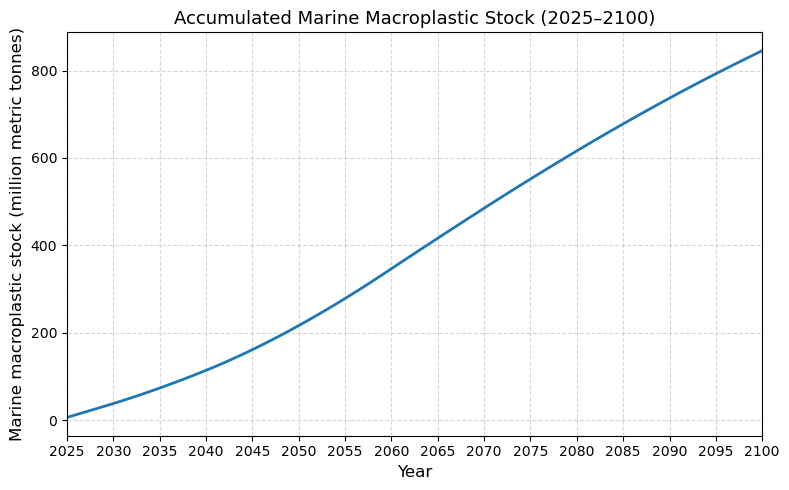

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the macroplastic stock results
map_stock_best_df = pd.read_csv("macroplastic_stock_by_year_best.csv")

# Convert kg → million metric tonnes (1 Mt = 1e9 kg)
map_stock_best_df["MaP_stock_Mt"] = map_stock_df["MaP_stock_kg"] / 1e9

# Plot
plt.figure(figsize=(8,5))
plt.plot(map_stock_best_df["year"], map_stock_best_df["MaP_stock_Mt"], linewidth=2)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Marine macroplastic stock (million metric tonnes)", fontsize=12)
plt.title("Accumulated Marine Macroplastic Stock (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.tight_layout()
plt.show()

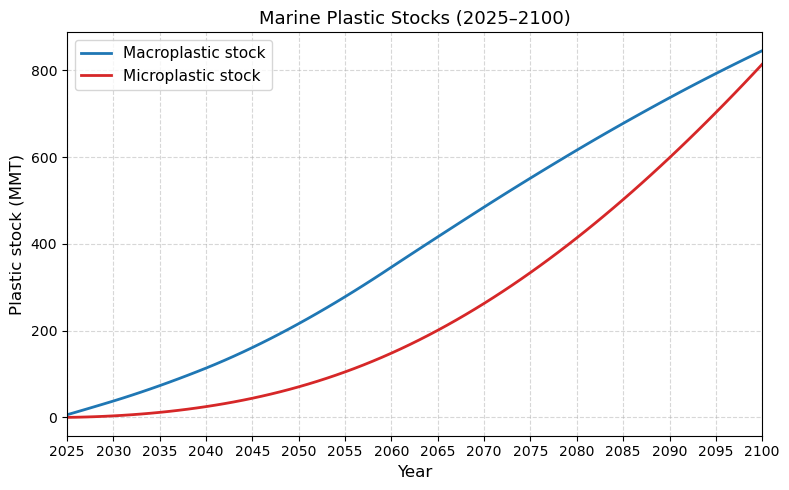

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load macro and micro stock data
map_df = pd.read_csv("macroplastic_stock_by_year.csv")
mip_df = pd.read_csv("microplastic_stock_by_year.csv")

# Ensure both are in MMT
map_df["MaP_stock_Mt"] = map_df["MaP_stock_kg"] / 1e9
mip_df["MiP_stock_Mt"] = mip_df["MiP_stock_kg"] / 1e9

# Merge by year
merged = pd.merge(map_df[["year", "MaP_stock_Mt"]],
                  mip_df[["year", "MiP_stock_Mt"]],
                  on="year", how="inner")

# Plot single axis with two series
plt.figure(figsize=(8,5))
plt.plot(merged["year"], merged["MaP_stock_Mt"], label="Macroplastic stock", linewidth=2, color="tab:blue")
plt.plot(merged["year"], merged["MiP_stock_Mt"], label="Microplastic stock", linewidth=2, color="tab:red")

plt.xlabel("Year", fontsize=12)
plt.ylabel("Plastic stock (MMT)", fontsize=12)
plt.title("Marine Plastic Stocks (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.legend(fontsize=11)
plt.tight_layout()

# Save the figure
plt.savefig("plastic_stocks.png", dpi=300)
plt.savefig("plastic_stocks.svg", format="svg")

plt.show()

# 4. Baseline SSP2 - With Bio/EoL/CCS technologies available immidiately today (Best)

### Add Carbon Capture

In [77]:
carbon_capture_decisions_df = pd.read_csv("data/carbon_capture_decisions.csv")

In [78]:
import numpy as np
import pandas as pd

# normalize for reliable matching
ekey = lambda s: str(s).strip().casefold()

# copies + keys
A_index_df = A_index_df.copy()
carbon_capture_decisions_df = carbon_capture_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
carbon_capture_decisions_df["col_key"] = carbon_capture_decisions_df["Provider name"].map(ekey)
carbon_capture_decisions_df["row_key"] = carbon_capture_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices (row/col) in A
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric X
carbon_capture_decisions_df["Best"] = pd.to_numeric(
    carbon_capture_decisions_df["Best"], errors="coerce"
)

# apply: for each decision row, A[row, col] *= X
n_pairs = 0
skipped = 0

for _, d in carbon_capture_decisions_df.iterrows():
    X = d["Best"]
    if pd.isna(X):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(X)
            n_pairs += 1

### Add Microplastic treatment

In [79]:
microplastics_decisions_df = pd.read_csv("data/microplastics_decisions.csv")

In [80]:
import numpy as np
import pandas as pd

# normalizer
ekey = lambda s: str(s).strip().casefold()

# copies + normalized keys
A_index_df = A_index_df.copy()
microplastics_decisions_df = microplastics_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
microplastics_decisions_df["col_key"] = microplastics_decisions_df["Provider name"].map(ekey)
microplastics_decisions_df["row_key"] = microplastics_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices in A (rows/cols)
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric decision value
microplastics_decisions_df["WWT Filtration"] = pd.to_numeric(
    microplastics_decisions_df["WWT Filtration"], errors="coerce"
)

# apply decisions: A[row, col] *= value
n_pairs = 0
skipped = 0

for _, d in microplastics_decisions_df.iterrows():
    x = d["WWT Filtration"]
    if pd.isna(x):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(x)
            n_pairs += 1

### Fix Bio-ethanol mix (25% of each second-gen)

In [81]:
import numpy as np
import pandas as pd

# Load the ethanol CSV
ethanol_df = pd.read_csv("data/dynamic ethanol.csv")

# Function to find index safely
def find_index(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Update A based on the baseline column
for _, r in ethanol_df.iterrows():
    provider = str(r["Provider name"])
    flow     = str(r["Input"])
    val      = float(r["baseline"])

    # Find indices
    row_idx = find_index(A_index_df, "flow name", flow)
    if row_idx is None:
        row_idx = find_index(A_index_df, "provider name", flow)
    col_idx = find_index(A_index_df, "provider name", provider)

    # Update A
    if (row_idx is not None) and (col_idx is not None):
        A[row_idx, col_idx] = val
    else:
        print(f"Warning: could not find indices for Provider={provider}, Flow={flow}")

### Baseline Collection & Sorting

In [82]:
packaging_types_df = pd.read_csv("data/packaging_types.csv")
collection_recyclate_df = pd.read_csv("data/collection_Recyclate.csv")
collection_msw_df = pd.read_csv("data/collection_MSW.csv")

In [83]:
import numpy as np
import pandas as pd
import re

# ---- exact-key matcher (case/space insensitive, keeps stage prefixes) ----
ekey = lambda s: str(s).strip().casefold()

# ---- copies + normalized keys ----
A_index_df = A_index_df.copy()
packaging_types_df = packaging_types_df.copy()
collection_msw_df = collection_msw_df.copy()

A_index_df["prov_exact"]         = A_index_df["provider name"].map(ekey)
packaging_types_df["prov_exact"] = packaging_types_df["provider name"].map(ekey)
collection_msw_df["prov_exact"]  = collection_msw_df["provider name"].map(ekey)

# If you know the 3 mapping columns, set them here, e.g.:
# mapping_cols = ["dest_1", "dest_2", "dest_3"]
# Otherwise, auto-detect up to 3 string columns besides 'provider name'
mapping_cols = [c for c in packaging_types_df.columns
                if c not in ("provider name", "prov_exact")
                and pd.api.types.is_string_dtype(packaging_types_df[c])][:3]
if not mapping_cols:
    raise ValueError("Couldn't detect mapping columns; please set 'mapping_cols' explicitly.")

# Normalize destination columns
for col in mapping_cols:
    packaging_types_df[col + "_exact"] = packaging_types_df[col].map(ekey)

# provider name -> list of integer indices in A (rows/cols)
idx_map_exact = (
    A_index_df.groupby("prov_exact")["index"]
              .apply(lambda s: list(map(int, s)))
              .to_dict()
)

# "Use & Collection" column index
use_col = int(A_index_df.loc[A_index_df["provider name"]=="Use & Collection","index"].iloc[0])

# ---- X: abs(A[row, use_col]) per packaging provider (exact match) ----
X_by_src = {}
for k in packaging_types_df["prov_exact"].dropna().unique():
    rows = idx_map_exact.get(k, [])
    if rows:
        r0 = int(rows[0])  # if multiple rows per provider, change to sum/mean if needed
        X_by_src[k] = abs(float(A[r0, use_col]))

# ---- Y: MSW "Linear Economy" per provider (exact match) ----
Y_by_key = (collection_msw_df.dropna(subset=["prov_exact"])
            .groupby("prov_exact")["High-tech"]
            .first()
            .to_dict())

# ---- zero out destination cells we're going to rewrite (avoid accumulation on reruns) ----
dest_rows = set()
for _, row in packaging_types_df.iterrows():
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if dk in idx_map_exact:
            dest_rows.update(idx_map_exact[dk])
if dest_rows:
    A[list(dest_rows), use_col] = 0.0

# ---- assign: A[row, use_col] += X * Y for each mapped destination (exact match) ----
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X     = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

In [84]:
# --- Recyclate pass: X * Y_recyclate added into A[:, use_col] ---

collection_recyclate_df = collection_recyclate_df.copy()
collection_recyclate_df["prov_exact"] = collection_recyclate_df["provider name"].map(ekey)

# Y from recyclate
Y_rec_by_key = (
    collection_recyclate_df.dropna(subset=["prov_exact"])
    .groupby("prov_exact")["High-tech"]
    .first()    # change to sum()/mean() if needed
    .to_dict()
)

# Optionally clear destination cells before this pass (default = keep MSW values and add recyclate)
reset_dest = False
if reset_dest:
    rec_dest_rows = set()
    for _, row in packaging_types_df.iterrows():
        for col in mapping_cols:
            dk = row.get(col + "_exact", None)
            rec_dest_rows.update(idx_map_exact.get(dk, []))
    if rec_dest_rows:
        A[np.array(sorted(rec_dest_rows), dtype=int), use_col] = 0.0

# Write: A[row, use_col] += X * Y_recyclate
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_rec_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

### Baseline Recycling

In [85]:
import numpy as np
import pandas as pd

# Load the CSV
recycling_df = pd.read_csv("data/dynamic-baseline-recycling-best.csv")

# Function to find index safely
def find_index(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Update A based on the baseline column
for _, r in recycling_df.iterrows():
    provider = str(r["Provider name"])
    flow     = str(r["Input parameters names"])
    val      = float(r["best case"])

    # Find indices
    row_idx = find_index(A_index_df, "flow name", flow)
    if row_idx is None:
        row_idx = find_index(A_index_df, "provider name", flow)
    col_idx = find_index(A_index_df, "provider name", provider)

    # Update A
    if (row_idx is not None) and (col_idx is not None):
        A[row_idx, col_idx] = val
    else:
        print(f"Warning: could not find indices for Provider={provider}, Flow={flow}")

In [86]:
A[A_index_df.loc[A_index_df['provider name'] == "Mechanical Recycling, HDPE Drinking Bottles (Flakes)", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Flakes, HDPE Drinking Bottles", 'index'].iloc[0]]

1.0

## Monomers

In [87]:
monomers_decisions_df = pd.read_csv("data/monomers_decisions.csv")

In [88]:
import numpy as np
import pandas as pd

# ---- helper: normalize names for reliable matching ----
ekey = lambda s: str(s).strip().casefold()

# ---- defensive copies + normalized keys ----
A_index_df = A_index_df.copy()
monomers_decisions_df = monomers_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
monomers_decisions_df["col_key"]  = monomers_decisions_df["Provider name"].map(ekey)
monomers_decisions_df["row_key"]  = monomers_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices in A (rows/cols)
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure "Linear Economy" is numeric
monomers_decisions_df["Best"] = pd.to_numeric(
    monomers_decisions_df["Best"], errors="coerce"
)

# ---- apply updates: for each row in decisions, scale A[row_idx, col_idx] *= X ----
n_pairs = 0
skipped = 0

for _, drow in monomers_decisions_df.iterrows():
    x = drow["Best"]
    if pd.isna(x):
        skipped += 1
        continue

    row_idxs = idx_map.get(drow["row_key"], [])
    col_idxs = idx_map.get(drow["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    # multiply all combinations (row, col) by X
    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(x)
            n_pairs += 1

In [89]:
A[A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride monomer, EDC-VCM; from bio-ethylene", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride", 'index'].iloc[0]]

-1.0

## Quality Scenario (for recycled material from mechanical)

In [90]:
quality_scenarios_df = pd.read_csv("data/quality_scenarios.csv")

In [91]:
# Assumes the following are already in memory:
# - quality_scenarios_df  with columns: "Recycling Process", "Substitutable Virgin Process", "S1 - no limit"
# - A_index_df            with columns: "Provider name", "Index"
# - A                     as a NumPy array (your A-matrix)

# Normalize helper (case-insensitive, trim spaces)
_norm = lambda s: str(s).strip().casefold()

# Build name -> index map from A_index_df
# If A_index_df['Index'] is 1-based, uncomment the "- 1" line below instead.
name_to_idx = {
    _norm(p): int(i)
    for p, i in zip(A_index_df["provider name"], A_index_df["index"])
    # for p, i in zip(A_index_df["Provider name"], A_index_df["Index"] - 1)  # <- use this if indices are 1-based
}

# Map processes to A indices
col_idx = quality_scenarios_df["Recycling Process"].astype(str).map(_norm).map(name_to_idx)
row_idx = quality_scenarios_df["Substitutable Virgin Process"].astype(str).map(_norm).map(name_to_idx)

# Save the pair (row, col) to the "Index" column
quality_scenarios_df["index"] = list(zip(row_idx, col_idx))

# Pull values to write
vals = pd.to_numeric(quality_scenarios_df["S1 - no limit"], errors="coerce")

# Only update where both indices and value are valid
mask = row_idx.notna() & col_idx.notna() & vals.notna()
rows = row_idx[mask].astype(int).to_numpy()
cols = col_idx[mask].astype(int).to_numpy()
v    = vals[mask].to_numpy(dtype=float)

# Write into A at (row, col)
A[rows, cols] = v

# Optional diagnostics:
# print("Updated entries:", mask.sum())
# print("Unmatched Recycling Process:", quality_scenarios_df.loc[col_idx.isna(), "Recycling Process"].drop_duplicates().tolist()[:10])
# print("Unmatched Substitutable Virgin Process:", quality_scenarios_df.loc[row_idx.isna(), "Substitutable Virgin Process"].drop_duplicates().tolist()[:10])


In [92]:
A[int(A_index_df.loc[A_index_df["provider name"]=="Polyethylene, high density, HDPE, virgin resin, food non-bottle grade","index"].iloc[0]),
  int(A_index_df.loc[A_index_df["provider name"]=="Mechanical Recycling, HDPE Other Food Rigid (Flakes)","index"].iloc[0])]

1.0

## Dynamic LCA

In [93]:
import numpy as np
import pandas as pd

# -----------------------------
# Load data
# -----------------------------
electricity_mix_df = pd.read_csv("data/electricity_mix_2025_2100.csv")
iam_indices_df     = pd.read_csv("data/iam-indices.csv")
packaging_df       = pd.read_csv("data/packaging_production_manual_2025_2100_kg.csv")

# -----------------------------
# Helpers
# -----------------------------
def first_idx(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Electricity Mix (Global) column index in A
mix_idx = int(A_index_df.loc[A_index_df['provider name'] == "Electricity Mix (Global)", 'index'].iloc[0])

# Map IAM electricity sources -> A row indices
iam_to_A = {}
for _, r in iam_indices_df.iterrows():
    lci_name = r["LCI Index"]
    hit = A_index_df.loc[A_index_df["provider name"] == lci_name, "index"]
    if not hit.empty:
        iam_to_A[str(r["IAM Index"])] = int(hit.iloc[0])

# -----------------------------
# Merge electricity mix and packaging data
# -----------------------------
merged_df = electricity_mix_df.merge(packaging_df, on="Year", how="inner")

results   = []
A_by_year = {}
f = np.zeros(len(A))

# -----------------------------
# Dynamic loop
# -----------------------------
for _, row in merged_df.iterrows():
    year = int(row["Year"])

    # 1) Build f
    n = A.shape[0]
    f = np.zeros(n)
    f[0] = float(row["Packaging_Plastic_kg"])

    # 2) Copy A and apply updates
    A_dyn = A.copy()

    # (a) Electricity mix: negative since it's an input
    for iam_source, idx in iam_to_A.items():
        if iam_source in row.index:
            A_dyn[idx, mix_idx] = -abs(float(row[iam_source]))/100

    # 3) Solve As = f
    s = np.linalg.solve(A_dyn, f)

    # 4) g = Bs
    g = B @ s

    # 5) Store results
    results.append({
        "year": year,
        "packaging_demand_kg": f[0],
        "g_vector": g,
        "s_vector": s
    })

    # 6) Store dynamic A
    A_by_year[year] = A_dyn.copy()

In [89]:
g_2100 = next(r['g_vector'] for r in results if r['year'] == 2100)

In [90]:
s_2100 = next(r['s_vector'] for r in results if r['year'] == 2100)

In [91]:
A_2100 = A_by_year[2100]

In [92]:
A_2100[A_index_df.loc[A_index_df['provider name'] == "Ethanol production, wheat straw, biochemical", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Ethanol (bio-mix)", 'index'].iloc[0]]

-0.25

### CO2 emissions 

In [94]:
import numpy as np
import pandas as pd

# Read target CO2 flows (names + categories)
co2_df = pd.read_csv("data/CO2.csv")  # cols: "flow name","flow category"

# Build a set of (name, category) pairs to match
target_pairs = set(zip(co2_df["flow name"].astype(str), co2_df["flow category"].astype(str)))

# Find matching row indices in B_index_df
mask = B_index_df.apply(
    lambda r: (str(r["flow name"]), str(r["flow category"])) in target_pairs, axis=1
)
co2_idx = B_index_df.loc[mask, "index"].astype(int).to_numpy()

if co2_idx.size == 0:
    raise ValueError("No CO2 flow rows found in B_index_df matching CO2.csv")

# Build per-year CO2 totals by summing g on those indices
co2_by_year = []
for r in results:
    g = r["g_vector"]
    year = int(r["year"])
    co2_sum = float(np.nansum(g[co2_idx]))
    co2_by_year.append({"year": year, "co2_sum": co2_sum})

co2_by_year_ssp2_best_df = pd.DataFrame(co2_by_year).sort_values("year")
co2_by_year_ssp2_best_df.to_csv("co2_by_year_ssp2_best.csv", index=False)

# Optional: keep indices used for traceability
pd.Series(co2_idx, name="co2_row_indices_in_B").to_csv("co2_row_indices_used.csv", index=False)

In [94]:
co2_by_year_ssp2_best_df.loc[co2_by_year_ssp1_best_df["year"] == 2025, "co2_sum"].iloc[0]

1806076362605.0269

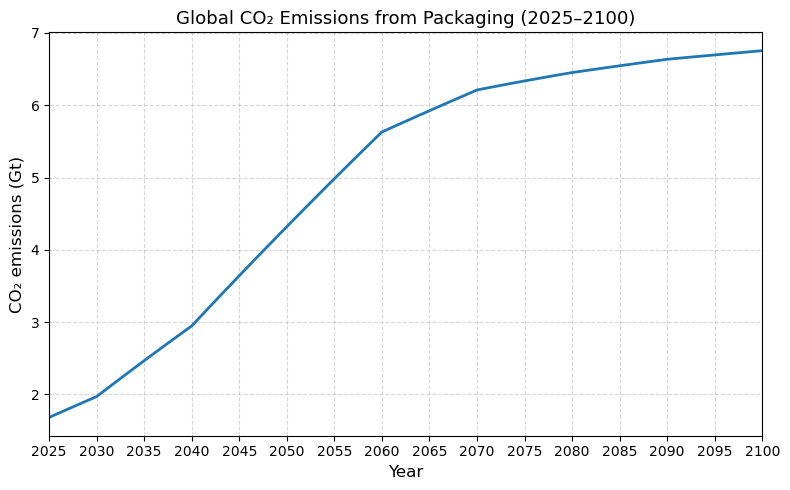

In [95]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Read the CO2 results
co2_by_year_ssp2_best_df = pd.read_csv("co2_by_year_ssp2_best.csv")

# Convert kg → gigatonnes (1 Gt = 1e12 kg)
co2_by_year_ssp2_best_df["CO2_Gt"] = co2_by_year_ssp2_best_df["co2_sum"] / 1e12

# Plot (line only, 5-year intervals)
plt.figure(figsize=(8,5))
plt.plot(co2_by_year_ssp2_best_df["year"], co2_by_year_ssp2_best_df["CO2_Gt"], linewidth=2)
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO₂ emissions (Gt)", fontsize=12)
plt.title("Global CO₂ Emissions from Packaging (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.tight_layout()

# Save the figure
plt.savefig("CO2_emissions_packaging_2025_2100.png", dpi=300)
plt.savefig("CO2_emissions_packaging_2025_2100.svg", format="svg")

# Show
plt.show()


In [59]:
s_2100 = next(r['s_vector'] for r in results if r['year'] == 2100)

In [60]:
# LCA Hotspots
# Impact per provider for category 0
CB = C @ B                                  # (n_impacts × n_providers)
contrib = s_2100 * CB[0, :]                      # contribution per provider
total_phi0 = contrib.sum()

# Use provider names from A_index_df
df = pd.DataFrame({
    "provider_name": A_index_df["provider name"].values,  # adjust column name if needed
    "contribution": contrib
})
df["share_%"] = 100 * df["contribution"] / total_phi0

# Top 10 contributors (by signed value)
top10 = df.sort_values("contribution", ascending=False).head(10)
print("\nTop 10 contributors to phi[0]:")
print(top10.reset_index(drop=True))

# If you want absolute-value ranking (credits vs burdens):
top10_abs = df.iloc[df["contribution"].abs().sort_values(ascending=False).index].head(10)
print("\nTop 10 contributors to phi[x] (absolute):")
print(top10_abs.reset_index(drop=True))


Top 10 contributors to phi[0]:
                                     provider_name  contribution    share_%
0      Natural gas, combusted in industrial boiler  2.446054e+12  44.477786
1            Muconic acid, fermentation of glucose  7.108857e+11  12.926377
2                      Switchgrass, harvested, wet  3.122042e+11   5.676959
3  Bituminous coal, combusted in industrial boiler  2.543864e+11   4.625631
4                  Electricity, solar (life cycle)  1.489236e+11   2.707950
5        Diesel, combusted in industrial equipment  1.169905e+11   2.127296
6            Electricity, natural gas (life cycle)  9.971323e+10   1.813134
7                   Electricity, coal (life cycle)  9.576447e+10   1.741331
8                              Quicklime, at plant  8.863382e+10   1.611671
9     Lignite coal, combusted in industrial boiler  7.958359e+10   1.447107

Top 10 contributors to phi[x] (absolute):
                                     provider_name  contribution    share_%
0      Natura

### Plastic packaging stocks in the ocean

In [47]:
import numpy as np
import pandas as pd

# --- Inputs assumed available ---
# results: list of dicts with keys {"year","g_vector",...}
# B_index_df: has columns ["index","flow name","flow category"] aligned to rows of B

# --- Load flow lists and degradation constants ---
map_flows_df = pd.read_csv("data/MaP.csv")                         # column: "flow name"
k_df         = pd.read_csv("data/fragmentation_cons_yearly.csv")   # columns: "Flow", "fragmentation constant"

# Build: flow_name -> k  (default to 0 if not present)
k_map = {str(r["Flow"]): float(r["fragmentation constant"]) for _, r in k_df.iterrows()}

# Find B row indices for each MaP flow (group by flow name; keep all matches)
flow_to_bidx = {}
for fname in map_flows_df["flow name"].astype(str).unique():
    idxs = B_index_df.loc[B_index_df["flow name"].astype(str) == fname, "index"].astype(int).to_numpy()
    if idxs.size > 0:
        flow_to_bidx[fname] = idxs

if not flow_to_bidx:
    raise ValueError("No MaP flow rows from MaP.csv were found in B_index_df['flow name'].")

# Prepare iteration over years (sorted)
years_sorted = sorted(int(r["year"]) for r in results)
# Per-flow stock state at previous year (initialize to 0 at 2024)
stock_prev = {fname: 0.0 for fname in flow_to_bidx.keys()}

rows = []   # to collect yearly totals and per-flow stocks if desired

for y in years_sorted:
    # get g for this year
    g = next(r["g_vector"] for r in results if int(r["year"]) == y)

    # update each flow's stock with its own k and A_y (kg/year)
    stock_now = {}
    for fname, bidx in flow_to_bidx.items():
        k = float(k_map.get(fname, 0.0))
        A_y = float(np.nansum(g[bidx]))  # generated macroplastic for this flow in year y
        stock_now[fname] = stock_prev[fname] * np.exp(-k) + A_y

    # total MaP stock this year
    total_map = float(np.sum(list(stock_now.values())))

    rows.append({"year": y, "MaP_stock_kg": total_map})
    # carry state
    stock_prev = stock_now

# Save total stock by year
map_stock_df = pd.DataFrame(rows).sort_values("year")
map_stock_df.to_csv("macroplastic_stock_by_year.csv", index=False)

# (Optional) also save per-flow stocks for debugging/analysis
perflow_rows = []
# replay quickly to materialize per-flow time series
stock_prev = {fname: 0.0 for fname in flow_to_bidx.keys()}
for y in years_sorted:
    g = next(r["g_vector"] for r in results if int(r["year"]) == y)
    row = {"year": y}
    for fname, bidx in flow_to_bidx.items():
        k = float(k_map.get(fname, 0.0))
        A_y = float(np.nansum(g[bidx]))
        stock_prev[fname] = stock_prev[fname] * np.exp(-k) + A_y
        row[fname] = stock_prev[fname]
    perflow_rows.append(row)

pd.DataFrame(perflow_rows).to_csv("macroplastic_stock_per_flow_by_year.csv", index=False)

In [48]:
import numpy as np
import pandas as pd

# Assumed available: results, B_index_df, map_flows_df (col "flow name"), k_df (cols "Flow","fragmentation constant")

# Map flow -> k
k_map = {str(r["Flow"]): float(r["fragmentation constant"]) for _, r in k_df.iterrows()}

# Map flow -> B row indices (each flow has its own set)
flow_to_bidx = {
    fname: B_index_df.loc[B_index_df["flow name"].astype(str)==fname, "index"].astype(int).to_numpy()
    for fname in map_flows_df["flow name"].astype(str).unique()
}
flow_to_bidx = {k:v for k,v in flow_to_bidx.items() if v.size>0}

years = sorted(int(r["year"]) for r in results)

# Initialize per-flow stocks at 0 for 2024
stock_prev = {flow: 0.0 for flow in flow_to_bidx.keys()}
rows = []                 # total per year (optional)
perflow_rows = []         # per-flow series (recommended)

for y in years:
    g = next(r["g_vector"] for r in results if int(r["year"])==y)
    stock_now = {}

    for flow, idxs in flow_to_bidx.items():
        k = float(k_map.get(flow, 0.0))
        decay = np.exp(-k)        # use (1 - k) instead if k is an annual fraction
        A_y = float(np.nansum(g[idxs]))  # this flow’s macroplastic generated in year y
        stock_now[flow] = stock_prev[flow] * decay + A_y

    # save per-flow stocks for this year
    rec = {"year": y}
    rec.update(stock_now)
    perflow_rows.append(rec)

    # optional total AFTER per-flow updates
    rows.append({"year": y, "MaP_stock_kg": float(sum(stock_now.values()))})

    # roll forward state
    stock_prev = stock_now

# DataFrames
map_stock_best_df      = pd.DataFrame(rows).sort_values("year")              # total (optional)
map_stock_best_perflow = pd.DataFrame(perflow_rows).sort_values("year")      # per-flow (preferred)

# Example save
map_stock_best_df.to_csv("macroplastic_stock_by_year_best.csv", index=False)
map_stock_best_perflow.to_csv("macroplastic_stock_best_per_flow_by_year_best.csv", index=False)

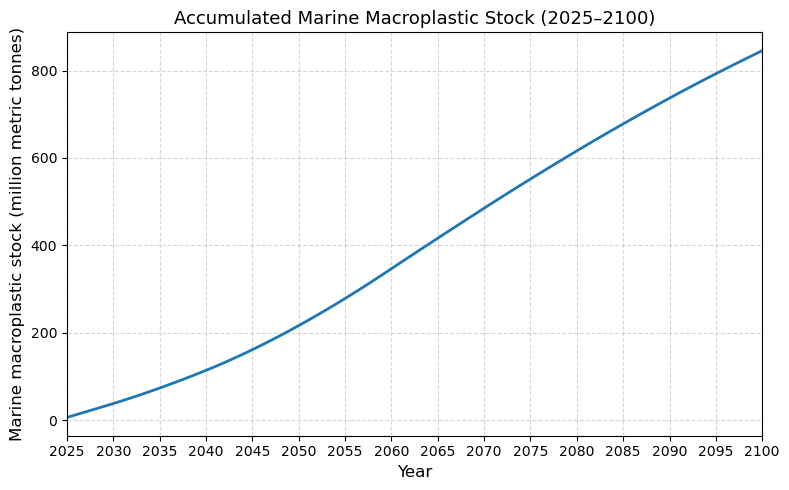

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the macroplastic stock results
map_stock_best_df = pd.read_csv("macroplastic_stock_by_year_best.csv")

# Convert kg → million metric tonnes (1 Mt = 1e9 kg)
map_stock_best_df["MaP_stock_Mt"] = map_stock_df["MaP_stock_kg"] / 1e9

# Plot
plt.figure(figsize=(8,5))
plt.plot(map_stock_best_df["year"], map_stock_best_df["MaP_stock_Mt"], linewidth=2)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Marine macroplastic stock (million metric tonnes)", fontsize=12)
plt.title("Accumulated Marine Macroplastic Stock (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.tight_layout()
plt.show()

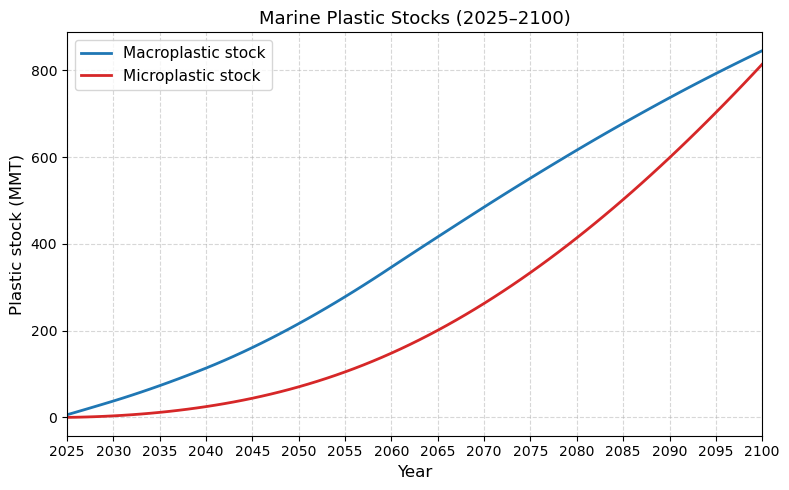

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load macro and micro stock data
map_df = pd.read_csv("macroplastic_stock_by_year.csv")
mip_df = pd.read_csv("microplastic_stock_by_year.csv")

# Ensure both are in MMT
map_df["MaP_stock_Mt"] = map_df["MaP_stock_kg"] / 1e9
mip_df["MiP_stock_Mt"] = mip_df["MiP_stock_kg"] / 1e9

# Merge by year
merged = pd.merge(map_df[["year", "MaP_stock_Mt"]],
                  mip_df[["year", "MiP_stock_Mt"]],
                  on="year", how="inner")

# Plot single axis with two series
plt.figure(figsize=(8,5))
plt.plot(merged["year"], merged["MaP_stock_Mt"], label="Macroplastic stock", linewidth=2, color="tab:blue")
plt.plot(merged["year"], merged["MiP_stock_Mt"], label="Microplastic stock", linewidth=2, color="tab:red")

plt.xlabel("Year", fontsize=12)
plt.ylabel("Plastic stock (MMT)", fontsize=12)
plt.title("Marine Plastic Stocks (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.legend(fontsize=11)
plt.tight_layout()

# Save the figure
plt.savefig("plastic_stocks.png", dpi=300)
plt.savefig("plastic_stocks.svg", format="svg")

plt.show()

# Visualization

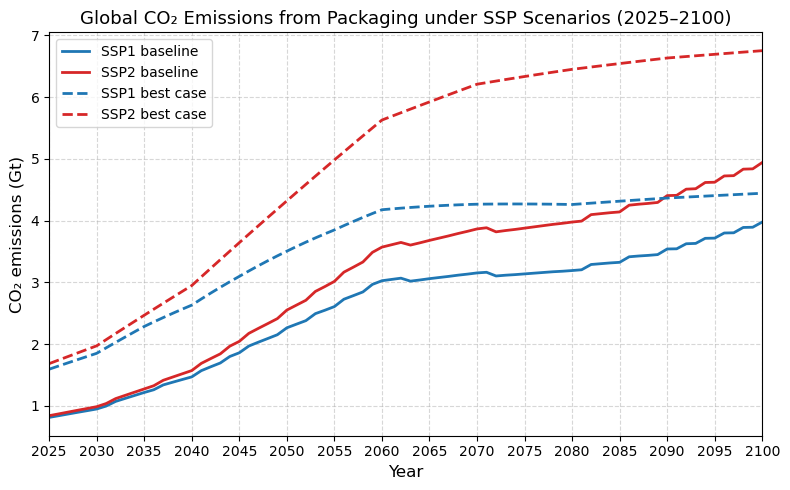

In [96]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Read all four datasets
co2_by_year_ssp1_df = pd.read_csv("co2_by_year_ssp1.csv")
co2_by_year_ssp2_df = pd.read_csv("co2_by_year_ssp2.csv")
co2_by_year_ssp1_best_df = pd.read_csv("co2_by_year_ssp1_best.csv")
co2_by_year_ssp2_best_df = pd.read_csv("co2_by_year_ssp2_best.csv")

# Convert kg → gigatonnes (1 Gt = 1e12 kg)
for df in [co2_by_year_ssp1_df, co2_by_year_ssp2_df, co2_by_year_ssp1_best_df, co2_by_year_ssp2_best_df]:
    df["CO2_Gt"] = df["co2_sum"] / 1e12

# Plot all scenarios
plt.figure(figsize=(8,5))

# Baseline scenarios
plt.plot(co2_by_year_ssp1_df["year"], co2_by_year_ssp1_df["CO2_Gt"], linewidth=2, color="tab:blue", label="SSP1 baseline")
plt.plot(co2_by_year_ssp2_df["year"], co2_by_year_ssp2_df["CO2_Gt"], linewidth=2, color="tab:red", label="SSP2 baseline")

# Best-case scenarios (dashed lines)
plt.plot(co2_by_year_ssp1_best_df["year"], co2_by_year_ssp1_best_df["CO2_Gt"], linewidth=2, linestyle="--", color="tab:blue", label="SSP1 best case")
plt.plot(co2_by_year_ssp2_best_df["year"], co2_by_year_ssp2_best_df["CO2_Gt"], linewidth=2, linestyle="--", color="tab:red", label="SSP2 best case")

# Labels and formatting
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO₂ emissions (Gt)", fontsize=12)
plt.title("Global CO₂ Emissions from Packaging under SSP Scenarios (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.legend(fontsize=10)
plt.tight_layout()

# Save figures
plt.savefig("CO2_emissions_packaging_SSP1_SSP2_bestcase_2025_2100.png", dpi=300)
plt.savefig("CO2_emissions_packaging_SSP1_SSP2_bestcase_2025_2100.svg", format="svg")

# Show plot
plt.show()

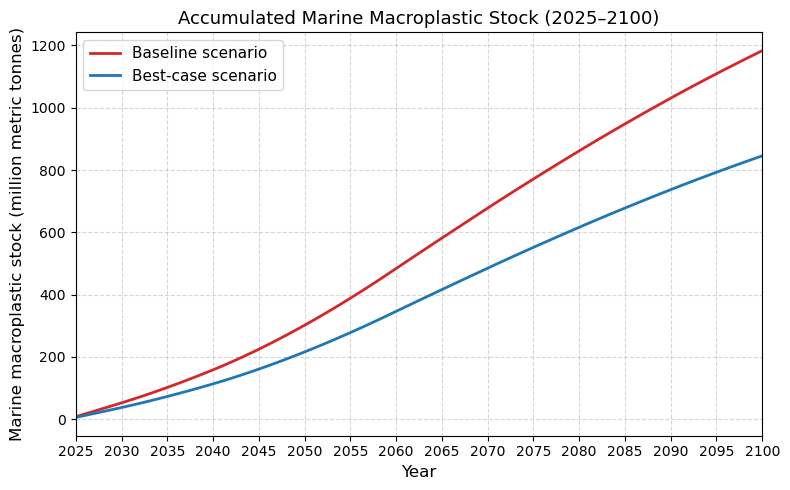

In [101]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load both datasets
map_stock_df = pd.read_csv("macroplastic_stock_by_year_baseline.csv")          # baseline
map_stock_best_df = pd.read_csv("macroplastic_stock_by_year_best.csv") # best case

# Convert kg → million metric tonnes (1 Mt = 1e9 kg)
map_stock_df["MaP_stock_Mt"] = map_stock_df["MaP_stock_kg"] / 1e9
map_stock_best_df["MaP_stock_Mt"] = map_stock_best_df["MaP_stock_kg"] / 1e9

# Plot both
plt.figure(figsize=(8,5))
plt.plot(map_stock_df["year"], map_stock_df["MaP_stock_Mt"], linewidth=2, color="tab:red", label="Baseline scenario")
plt.plot(map_stock_best_df["year"], map_stock_best_df["MaP_stock_Mt"], linewidth=2, color="tab:blue", label="Best-case scenario")

plt.xlabel("Year", fontsize=12)
plt.ylabel("Marine macroplastic stock (million metric tonnes)", fontsize=12)
plt.title("Accumulated Marine Macroplastic Stock (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.legend(fontsize=11)
plt.tight_layout()

# Save figures
plt.savefig("Macroplastic_stock_baseline_vs_bestcase_2025_2100.png", dpi=300)
plt.savefig("Macroplastic_stock_baseline_vs_bestcase_2025_2100.svg", format="svg")

# Show
plt.show()